## Ecoli peptide sequencing

We first install the latest instanovo from PyPi

In [ ]:
try:
  import instanovo
except ImportError:
  !uv pip install "instanovo[cu126]>=1.2.2" pyopenms-viz
  print('Installation complete. Restarting runtime to apply changes...')
  import os
  os.kill(os.getpid(), 9)

Set the device to GPU if available (recommended), otherwise use CPU.

In [ ]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [ ]:
# Filter warnings and set logging level
import warnings
import logging

warnings.filterwarnings("ignore", module="matplotlib")
warnings.filterwarnings("ignore", module="torch")
logging.getLogger("matplotlib").setLevel(logging.WARNING)
logging.getLogger("rdkit").setLevel(logging.WARNING)

We can use `instanovo version` to check the version of InstaNovo (the transformer-based model), InstaNovo+ (the diffusion-based model) and some of their dependencies.

In [ ]:
!instanovo version

┏━━━━━━━━━━━━┳━━━━━━━━━━━━━━┓
┃ Package    ┃ Version      ┃
┡━━━━━━━━━━━━╇━━━━━━━━━━━━━━┩
│ InstaNovo  │ 1.2.2        │
│ InstaNovo+ │ 1.2.2        │
│ NumPy      │ 2.2.6        │
│ PyTorch    │ 2.10.0+cu128 │
└────────────┴──────────────┘


Import the transformer-based InstaNovo model.

In [ ]:
from instanovo.transformer.model import InstaNovo

InstaNovo supports automatic model downloads. You can see the IDs of the pretrained models that are available.

In [ ]:
InstaNovo.get_pretrained()

['instanovo-v1.2.0',
 'instanovo-v1.1.0',
 'instanovo-v1.0.0',
 'instanovo-phospho-v1.0.0']

And download the model checkpoint given the ID.

In [ ]:
model, config = InstaNovo.from_pretrained("instanovo-v1.2.0")
model = model.to(device).eval()

instanovo-v1.2.0.ckpt: 100%|██████████| 362M/362M [00:20<00:00, 18.7MiB/s]
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Can only SETITEM for dict, collections.OrderedDict, collections.Counter, but got <class 'collections.defaultdict'>

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.
instanovo-v1.2.0.ckpt: 100%|██████████| 362M/362M [00:03<00:00, 115MiB/s]


UnpicklingError: Weights only load failed. In PyTorch 2.6, we changed the default value of the `weights_only` argument in `torch.load` from `False` to `True`. Re-running `torch.load` with `weights_only` set to `False` will likely succeed, but it can result in arbitrary code execution. Do it only if you got the file from a trusted source.
Please file an issue with the following so that we can make `weights_only=True` compatible with your use case: WeightsUnpickler error: 

Can only SETITEM for dict, collections.OrderedDict, collections.Counter, but got <class 'collections.defaultdict'>

Check the documentation of torch.load to learn more about types accepted by default with weights_only https://pytorch.org/docs/stable/generated/torch.load.html.

## Loading the dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
from instanovo.utils.data_handler import SpectrumDataFrame

# Lets do preprocessing for Waste water sample 1
sdf = SpectrumDataFrame.load_mzml("/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML")

In [ ]:
df = sdf.to_pandas().copy()

print("shape:", df.shape)
print(df.columns.tolist())
print(df.dtypes)
display(df.head(3))

shape: (17100, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,40,,1480.379368,741.19696,2,0.167837,"[136.38525390625, 143.05569458007812, 149.0447...","[1134.8853759765625, 1557.720458984375, 1477.0..."
1,166,,1366.393408,684.20398,2,0.711286,"[118.62577056884766, 149.045166015625, 167.055...","[1169.7818603515625, 3631.05126953125, 1690.52..."
2,257,,1514.430768,758.22266,2,1.103036,"[112.7114486694336, 112.89521789550781, 117.23...","[1333.8302001953125, 1128.4227294921875, 1125...."


In [ ]:
null_counts = df.isnull().sum()
print(null_counts)

scan_number         0
sequence            0
precursor_mass      0
precursor_mz        0
precursor_charge    0
retention_time      0
mz_array            0
intensity_array     0
dtype: int64


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

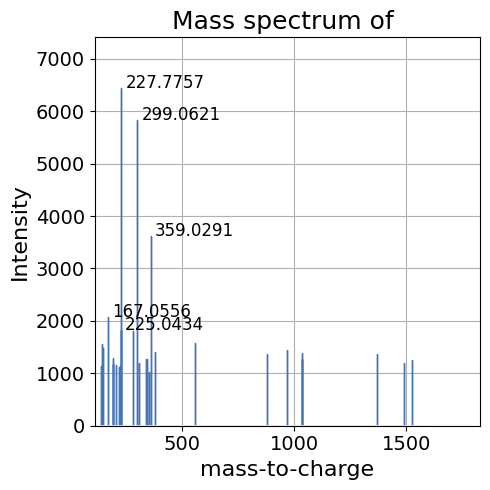

In [ ]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);

In [ ]:
# Lets do preprocessing for one of the Ecoli sample.

Ecoli_sdf = SpectrumDataFrame.load_mzml("/content/drive/MyDrive/E_coli/Ecoli_EV_1.mzML")

In [ ]:
Ecoli_df = Ecoli_sdf.to_pandas().copy()

print("shape:", Ecoli_df.shape)
print(Ecoli_df.columns.tolist())
print(Ecoli_df.dtypes)
display(Ecoli_df.head(3))

shape: (10881, 8)
['scan_number', 'sequence', 'precursor_mass', 'precursor_mz', 'precursor_charge', 'retention_time', 'mz_array', 'intensity_array']
scan_number           int64
sequence             object
precursor_mass      float64
precursor_mz        float64
precursor_charge      int64
retention_time      float64
mz_array             object
intensity_array      object
dtype: object


,scan_number,sequence,precursor_mass,precursor_mz,precursor_charge,retention_time,mz_array,intensity_array
0,95,,832.727148,417.37085,2,0.407458,"[108.90433879457866, 108.90479357490754, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 677.9..."
1,169,,1301.626602,434.88281,3,0.726686,"[108.9043793591056, 108.90483413943026, 108.90...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 411.7..."
2,277,,840.644268,421.32941,2,1.194676,"[108.90433891446301, 108.90479369479279, 108.9...","[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 577.4..."


In [ ]:
ecoli_null_counts = df.isnull().sum()
print(ecoli_null_counts)

scan_number         0
sequence            0
precursor_mass      0
precursor_mz        0
precursor_charge    0
retention_time      0
mz_array            0
intensity_array     0
dtype: int64


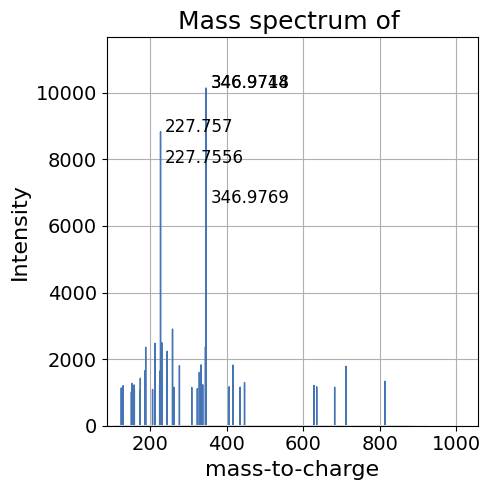

In [ ]:
import pandas as pd

pd.options.plotting.backend = "ms_matplotlib"
row = Ecoli_sdf[0]
row_df = pd.DataFrame({"mz": row["mz_array"], "intensity": row["intensity_array"]})
row_df.plot(
    kind="spectrum",
    x="mz",
    y="intensity",
    annotate_mz=True,
    bin_method="none",
    annotate_top_n_peaks=5,
    aggregate_duplicates=True,
    title=f"Mass spectrum of {row['sequence']}",
);

## Prediction

So we have one E. coli EV data with two fractions (Ecoli_EV_1 and Ecoli_EV_2). Results
from these two files can be combined.
We have two wastewater samples (wastewater_sample1 and wastewater_sample2). Each
has two fractions (*_1 and *_2). So combine the results from
wastewater_Sample1_1 and wastewater_Sample1_2 as Sample 1, and combine the
results from wastewater_Sample2_1 and wastewater_Sample2_2 as Sample 2

| Sample       | Input Files                                     | InstaNovo Output            | InstaNovo+ Output          | Casanovo Output           |
|--------------|-------------------------------------------------|-----------------------------|----------------------------|---------------------------|
| E. coli EV   | `Ecoli_EV_1.mzML`, `Ecoli_EV_2.mzML`            | `instanovo_Ecoli_preds.csv` | `instanovo+_Ecoli_preds.csv`| `casanovo_Ecoli_mzTab.tsv`|
| Wastewater 1 | `wastewater_Sample1_1.mzML`, `wastewater_Sample1_2.mzML` | `instanovo_wastewater1_preds.csv` | `instanovo+_wastewater1_preds.csv` | `casanovo_wastewater1_mzTab.tsv` |
| Wastewater 2 | `wastewater_Sample2_1.mzML`, `wastewater_Sample2_2.mzML` | `instanovo_wastewater2_preds.csv` | `instanovo+_wastewater2_preds.csv` | `casanovo_wastewater2_mzTab.tsv` |

In [ ]:
!ls /content/drive/MyDrive/Wastewater

wastewater_Sample1_1.mzML  wastewater_Sample2_1.mzML
wastewater_Sample1_2.mzML  wastewater_Sample2_2.mzML


In [ ]:
# InstaNovo (base model) predictions
!instanovo predict --data-path "/content/drive/MyDrive/E_coli/Ecoli_EV_1.mzML" --output-path instanovo_Ecoli_preds1.csv



[04/18/26 05:30:54] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/18/26 05:30:56] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-18 05:30:59.376598: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 05:30:59.395468: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776490259.417826   16663 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/E_coli/Ecoli_EV_2.mzML" --output-path instanovo_Ecoli_preds2.csv



[04/18/26 05:50:30] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/18/26 05:50:32] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-18 05:50:35.011847: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-18 05:50:35.030931: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776491435.053441   21876 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
import pandas as pd
import numpy as np
import re

ecoli_preds1 = pd.read_csv('instanovo_Ecoli_preds1.csv')
ecoli_preds2 = pd.read_csv('instanovo_Ecoli_preds2.csv')


ecoli_preds1[['instanovo_predictions', 'instanovoplus_predictions']].head(5)

,instanovo_predictions,instanovoplus_predictions
0,"['S', 'P', 'S[UNIMOD:21]', 'L', 'S', 'P', 'K']","['C[UNIMOD:4]', 'V', 'E', 'L', 'S', 'P', 'K']"
1,"['L', 'A', 'L', 'A', 'G', 'G', 'G', 'I', 'A', ...","['A', 'A', 'S', 'E', 'G', 'G', 'Q', 'S', 'S', ..."
2,"['G', 'E', 'M[UNIMOD:35]', 'G', 'G', 'Y', 'G',...","['G', 'P', 'N', 'G', 'G', 'Y', 'G', 'K']"
3,"['A', 'P', 'S[UNIMOD:21]', 'P', 'P', 'P', 'R']","['E', 'V', 'F', 'P', 'P', 'N', 'R']"
4,"['V', 'E', 'G', 'A', 'L', 'S', 'E', 'V', 'T', ...","['M[UNIMOD:35]', 'V', 'G', 'A', 'L', 'S', 'M',..."


In [ ]:
import pandas as pd
# Load DB search results
db1 = pd.read_excel('/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_1.xlsx')
db2 = pd.read_excel('/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_2.xlsx')


print(f'Total raw DB rows: {len(db1)}')
print('DB columns:')
print(db1.columns.tolist())

Total raw DB rows: 1495
DB columns:
['Scan number', 'Scan index', 'Sequence', 'Length', 'Missed cleavages', 'Modifications', 'Modified sequence', 'Oxidation (M) Probabilities', 'Oxidation (M) Score diffs', 'Acetyl (Protein N-term)', 'Oxidation (M)', 'Charge', 'Scan event number', 'm/z', 'Mass', 'Mass error [ppm]', 'Mass error [Da]', 'Simple mass error [ppm]', 'Retention time', 'PEP', 'Score', 'Delta score', 'Precursor full scan number', 'Precursor Intensity', 'Precursor apex fraction', 'Precursor apex offset', 'Precursor apex offset time', 'Matches', 'Intensities', 'Mass deviations [Da]', 'Mass deviations [ppm]', 'Masses', 'Number of matches', 'Intensity coverage', 'Peak coverage', 'Unfragmented precursor intensity', 'Unfragmented precursor fraction', 'Neutral loss level', 'ETD identification type', 'Contaminant']


In [ ]:
import pandas as pd
import numpy as np
import re
import ast

# =========================================================
# 1) amino acid masses
# =========================================================
AA_MASS = {
    'A': 71.03711,
    'R': 156.10111,
    'N': 114.04293,
    'N(Deamidation)': 115.02695,
    'D': 115.02694,
    'C': 103.00919,
    'C(Carbamidomethylation)': 160.03065,
    'E': 129.04259,
    'Q': 128.05858,
    'Q(Deamidation)': 129.04260,
    'G': 57.02146,
    'H': 137.05891,
    'I': 113.08406,
    'L': 113.08406,
    'K': 128.09496,
    'M': 131.04049,
    'M(Oxidation)': 147.03540,
    'F': 147.06841,
    'P': 97.05276,
    'S': 87.03203,
    'S(Phosphorylation)': 166.99836,
    'T': 101.04768,
    'T(Phosphorylation)': 181.01401,
    'W': 186.07931,
    'Y': 163.06333,
    'Y(Phosphorylation)': 243.02966,
    'V': 99.06841,
}

AA_TOL = 0.1
PREFIX_TOL = 0.5

# =========================================================
# 2) basic helpers
# =========================================================
def clean_colnames(df):
    df = df.copy()
    df.columns = [
        re.sub(r'[^a-z0-9]+', '_', c.strip().lower()).strip('_')
        for c in df.columns
    ]
    return df

def first_existing(df, candidates, required=True):
    for c in candidates:
        if c in df.columns:
            return c
    if required:
        raise KeyError(f"None of these columns found: {candidates}")
    return None

def blank_to_none(x):
    if pd.isna(x):
        return None
    s = str(x).strip()
    if s == "" or s.lower() == "nan":
        return None
    return s

# =========================================================
# 3) modification normalization
# =========================================================
def normalize_mod_token(aa, mod_text):
    aa = aa.upper()
    if mod_text is None or str(mod_text).strip() == "":
        return aa

    m = str(mod_text).strip().lower().replace(" ", "")

    if aa == "M" and ("oxid" in m or "+15.99" in m or "+15.994" in m or "+16" in m):
        return "M(Oxidation)"

    if aa == "C" and ("carbamidomethyl" in m or "+57.02" in m or "+57.021" in m):
        return "C(Carbamidomethylation)"

    if aa == "N" and ("deamid" in m or "+0.98" in m or "+0.984" in m):
        return "N(Deamidation)"

    if aa == "Q" and ("deamid" in m or "+0.98" in m or "+0.984" in m):
        return "Q(Deamidation)"

    if aa == "S" and ("phosph" in m or "+79.96" in m or "+79.966" in m):
        return "S(Phosphorylation)"

    if aa == "T" and ("phosph" in m or "+79.96" in m or "+79.966" in m):
        return "T(Phosphorylation)"

    if aa == "Y" and ("phosph" in m or "+79.96" in m or "+79.966" in m):
        return "Y(Phosphorylation)"

    return aa

# =========================================================
# 4) instanovo token handling
# =========================================================
UNIMOD_TOKEN_MAP = {
    "C[UNIMOD:4]": "C(Carbamidomethylation)",
    "M[UNIMOD:35]": "M(Oxidation)",
    "S[UNIMOD:21]": "S(Phosphorylation)",
    "T[UNIMOD:21]": "T(Phosphorylation)",
    "Y[UNIMOD:21]": "Y(Phosphorylation)",
}

UNIMOD_RE = re.compile(r"^([A-Z])\[UNIMOD:(\d+)\]$")
TOKEN_RE = re.compile(r'([A-Z])(?:\(([^()]*)\)|\[([^\[\]]*)\]|\{([^{}]*)\})?')

def normalize_instanovo_token(tok):
    if tok is None:
        return None

    tok = str(tok).strip().strip("'").strip('"')

    if tok in UNIMOD_TOKEN_MAP:
        return UNIMOD_TOKEN_MAP[tok]

    m = UNIMOD_RE.match(tok)
    if m:
        aa, mod_id = m.groups()
        return UNIMOD_TOKEN_MAP.get(f"{aa}[UNIMOD:{mod_id}]", aa)

    if re.fullmatch(r"[A-Z]", tok):
        return tok

    return tok

def clean_instanovo_prediction(seq):
    if pd.isna(seq):
        return None

    s = str(seq).strip()
    if s == "" or s.lower() == "nan":
        return None

    # parse stringified python list like:
    # "['S', 'P', 'S[UNIMOD:21]', 'L']"
    try:
        parsed = ast.literal_eval(s)
        if isinstance(parsed, list):
            toks = [normalize_instanovo_token(t) for t in parsed]
            toks = [t for t in toks if t is not None and str(t).strip() != ""]
            return toks if len(toks) > 0 else None
    except Exception:
        pass

    # fallback for plain peptide strings
    s = s.replace(" ", "")
    s = re.sub(r"[^A-Z]", "", s)
    if s == "":
        return None
    return list(s)

# =========================================================
# 5) sequence tokenization
# =========================================================
def tokenize_sequence(seq):
    if seq is None:
        return []

    if isinstance(seq, float) and pd.isna(seq):
        return []

    # already cleaned instanovo list
    if isinstance(seq, list):
        toks = [normalize_instanovo_token(t) for t in seq]
        toks = [t for t in toks if t is not None and str(t).strip() != ""]
        return toks

    s = str(seq).strip()
    if s == "" or s.lower() == "nan":
        return []

    s = s.replace("_", "").replace(".", "").replace(" ", "")

    # common replacements
    s = s.replace("Oxidation(M)", "M(Oxidation)")
    s = s.replace("M[Oxidation]", "M(Oxidation)")
    s = s.replace("M[+15.9949]", "M(Oxidation)")
    s = s.replace("C[Carbamidomethyl]", "C(Carbamidomethylation)")
    s = s.replace("C[+57.0215]", "C(Carbamidomethylation)")
    s = s.replace("S[Phosphorylation]", "S(Phosphorylation)")
    s = s.replace("T[Phosphorylation]", "T(Phosphorylation)")
    s = s.replace("Y[Phosphorylation]", "Y(Phosphorylation)")

    if re.fullmatch(r"[A-Z]+", s):
        return list(s)

    tokens = []
    pos = 0
    for m in TOKEN_RE.finditer(s):
        if m.start() != pos:
            junk = s[pos:m.start()]
            if junk not in ("", "-", "/"):
                return []
        aa = m.group(1)
        mod = next((g for g in m.groups()[1:] if g is not None), None)
        tok = normalize_mod_token(aa, mod)
        tokens.append(tok)
        pos = m.end()

    if pos != len(s):
        return []

    return tokens

def canonical_sequence(seq):
    toks = tokenize_sequence(seq)
    if not toks:
        return None
    return toks

def token_masses(tokens):
    masses = []
    for t in tokens:
        if t not in AA_MASS:
            return None
        masses.append(AA_MASS[t])
    return masses

# =========================================================
# 6) novoboard-style matching
# =========================================================
def one_direction_match(pred_tokens, gt_tokens, aa_tol=AA_TOL, prefix_tol=PREFIX_TOL):
    pred_m = token_masses(pred_tokens)
    gt_m = token_masses(gt_tokens)

    if pred_m is None or gt_m is None:
        return set(), set()

    i = 0
    j = 0
    pred_prefix = 0.0
    gt_prefix = 0.0

    pred_matched = set()
    gt_matched = set()

    while i < len(pred_m) and j < len(gt_m):
        next_pred = pred_prefix + pred_m[i]
        next_gt = gt_prefix + gt_m[j]

        if abs(next_pred - next_gt) <= prefix_tol:
            if abs(pred_m[i] - gt_m[j]) < aa_tol:
                pred_matched.add(i)
                gt_matched.add(j)
            pred_prefix = next_pred
            gt_prefix = next_gt
            i += 1
            j += 1
        elif next_pred < next_gt:
            pred_prefix = next_pred
            i += 1
        else:
            gt_prefix = next_gt
            j += 1

    return pred_matched, gt_matched

def novoboard_match(pred_seq, gt_seq, aa_tol=AA_TOL, prefix_tol=PREFIX_TOL):
    pred_tokens = tokenize_sequence(pred_seq)
    gt_tokens = tokenize_sequence(gt_seq)

    if len(pred_tokens) == 0 or len(gt_tokens) == 0:
        return {
            "pred_len": len(pred_tokens),
            "gt_len": len(gt_tokens),
            "aa_matches": 0,
            "peptide_match": 0,
        }

    f_pred, f_gt = one_direction_match(pred_tokens, gt_tokens, aa_tol, prefix_tol)

    r_pred_tmp, r_gt_tmp = one_direction_match(pred_tokens[::-1], gt_tokens[::-1], aa_tol, prefix_tol)
    r_pred = {len(pred_tokens) - 1 - i for i in r_pred_tmp}
    r_gt = {len(gt_tokens) - 1 - j for j in r_gt_tmp}

    pred_matched = f_pred | r_pred
    gt_matched = f_gt | r_gt

    aa_matches = min(len(pred_matched), len(gt_matched))

    peptide_match = int(
        len(pred_tokens) == len(gt_tokens) and
        len(pred_matched) == len(pred_tokens) and
        len(gt_matched) == len(gt_tokens)
    )

    return {
        "pred_len": len(pred_tokens),
        "gt_len": len(gt_tokens),
        "aa_matches": aa_matches,
        "peptide_match": peptide_match,
    }

# =========================================================
# 7) prepare db
# =========================================================
def prepare_db(df, fraction_name):
    df = clean_colnames(df)

    scan_col = first_existing(df, ["scan_number", "scan"])
    seq_col = first_existing(df, ["sequence"], required=False)
    mod_seq_col = first_existing(df, ["modified_sequence"], required=False)
    pep_col = first_existing(df, ["pep"], required=False)
    score_col = first_existing(df, ["score"], required=False)

    out = df.copy()
    out["scan_number"] = pd.to_numeric(out[scan_col], errors="coerce").astype("Int64")

    def choose_gt(row):
        mod_seq = blank_to_none(row[mod_seq_col]) if mod_seq_col else None
        seq = blank_to_none(row[seq_col]) if seq_col else None
        return mod_seq if mod_seq is not None else seq

    out["ground_truth_raw"] = out.apply(choose_gt, axis=1)
    out["ground_truth"] = out["ground_truth_raw"].apply(canonical_sequence)
    out["fraction"] = fraction_name

    sort_cols = ["scan_number"]
    ascending = [True]

    if pep_col is not None:
        sort_cols.append(pep_col)
        ascending.append(True)
    elif score_col is not None:
        sort_cols.append(score_col)
        ascending.append(False)

    out = (
        out.sort_values(sort_cols, ascending=ascending)
           .drop_duplicates(subset=["scan_number"], keep="first")
           .reset_index(drop=True)
    )

    keep_cols = ["fraction", "scan_number", "ground_truth_raw", "ground_truth"]
    if pep_col is not None:
        keep_cols.append(pep_col)
    if score_col is not None:
        keep_cols.append(score_col)

    return out[keep_cols]

# =========================================================
# 8) prepare predictions
# =========================================================
def prepare_preds(df, fraction_name):
    df = clean_colnames(df)

    scan_col = first_existing(df, ["scan_number"])
    out = df.copy()
    out["scan_number"] = pd.to_numeric(out[scan_col], errors="coerce").astype("Int64")
    out["fraction"] = fraction_name

    if "instanovo_predictions" in out.columns:
        out["instanovo_predictions_clean"] = out["instanovo_predictions"].apply(clean_instanovo_prediction)

    if "instanovoplus_predictions" in out.columns:
        out["instanovoplus_predictions_clean"] = out["instanovoplus_predictions"].apply(clean_instanovo_prediction)

    score_candidates = [
        c for c in [
            "instanovo_prediction_log_probability",
            "instanovoplus_prediction_log_probability"
        ] if c in out.columns
    ]

    if score_candidates:
        tmp_score = out[score_candidates].max(axis=1)
        out = out.assign(_best_score=tmp_score)
        out = (
            out.sort_values(["scan_number", "_best_score"], ascending=[True, False])
               .drop_duplicates(subset=["scan_number"], keep="first")
               .drop(columns=["_best_score"])
               .reset_index(drop=True)
        )
    else:
        out = out.drop_duplicates(subset=["scan_number"], keep="first").reset_index(drop=True)

    return out

# =========================================================
# 9) merge one fraction
# =========================================================
def merge_fraction(db_path, pred_path, fraction_name):
    db = pd.read_excel(db_path)
    pr = pd.read_csv(pred_path)

    db_p = prepare_db(db, fraction_name)
    pr_p = prepare_preds(pr, fraction_name)

    merged = db_p.merge(
        pr_p,
        on=["fraction", "scan_number"],
        how="inner"
    )

    print(f"\n=== {fraction_name} ===")
    print("DB rows:", len(db_p))
    print("Pred rows:", len(pr_p))
    print("Merged rows:", len(merged))
    print("GT non-null:", merged["ground_truth"].notna().sum())

    if "instanovo_predictions_clean" in merged.columns:
        print("InstaNovo non-null:", merged["instanovo_predictions_clean"].notna().sum())

    if "instanovoplus_predictions_clean" in merged.columns:
        print("InstaNovo+ non-null:", merged["instanovoplus_predictions_clean"].notna().sum())

    return merged

# =========================================================
# 10) evaluate model
# =========================================================
def evaluate_model(df, pred_col, score_col=None, sample_name="sample"):
    work = df.copy()

    if pred_col not in work.columns:
        raise KeyError(f"{pred_col} not found in dataframe columns")

    work = work[
        work["ground_truth"].notna() &
        work[pred_col].notna()
    ].copy()

    if len(work) == 0:
        summary = {
            "sample": sample_name,
            "model": pred_col,
            "n_scans_evaluated": 0,
            "aa_matches": 0,
            "total_pred_aa": 0,
            "total_gt_aa": 0,
            "peptide_matches": 0,
            "aa_precision": np.nan,
            "aa_recall": np.nan,
            "peptide_precision": np.nan,
            "peptide_recall": np.nan,
        }
        empty_cols = list(work.columns) + ["pred_len", "gt_len", "aa_matches", "peptide_match"]
        return summary, pd.DataFrame(columns=empty_cols), None

    stats_rows = [
        novoboard_match(row[pred_col], row["ground_truth"])
        for _, row in work.iterrows()
    ]
    stats = pd.DataFrame(stats_rows)

    for c in ["pred_len", "gt_len", "aa_matches", "peptide_match"]:
        if c not in stats.columns:
            stats[c] = 0

    work = work.reset_index(drop=True)
    stats = stats.reset_index(drop=True)
    work = pd.concat([work, stats], axis=1)

    n_scans = len(work)
    aa_matches = work["aa_matches"].sum()
    total_pred_aa = work["pred_len"].sum()
    total_gt_aa = work["gt_len"].sum()
    peptide_matches = work["peptide_match"].sum()

    aa_precision = aa_matches / total_pred_aa if total_pred_aa > 0 else np.nan
    aa_recall = aa_matches / total_gt_aa if total_gt_aa > 0 else np.nan
    peptide_precision = peptide_matches / n_scans if n_scans > 0 else np.nan
    peptide_recall = peptide_matches / n_scans if n_scans > 0 else np.nan

    summary = {
        "sample": sample_name,
        "model": pred_col,
        "n_scans_evaluated": n_scans,
        "aa_matches": int(aa_matches),
        "total_pred_aa": int(total_pred_aa),
        "total_gt_aa": int(total_gt_aa),
        "peptide_matches": int(peptide_matches),
        "aa_precision": aa_precision,
        "aa_recall": aa_recall,
        "peptide_precision": peptide_precision,
        "peptide_recall": peptide_recall,
    }

    curve_df = None
    if score_col is not None and score_col in work.columns:
        score_series = pd.to_numeric(work[score_col], errors="coerce")
        score_vals = score_series.dropna()

        if len(score_vals) > 0:
            thresholds = np.unique(np.quantile(score_vals, np.linspace(0, 1, 21)))
            curve_rows = []
            total_all = len(work)

            for thr in thresholds:
                sub = work[pd.to_numeric(work[score_col], errors="coerce") >= thr].copy()
                if len(sub) == 0:
                    continue

                aa_m = sub["aa_matches"].sum()
                pred_aa = sub["pred_len"].sum()
                gt_aa = sub["gt_len"].sum()
                pep_m = sub["peptide_match"].sum()

                curve_rows.append({
                    "threshold": thr,
                    "coverage": len(sub) / total_all,
                    "aa_precision": aa_m / pred_aa if pred_aa > 0 else np.nan,
                    "aa_recall": aa_m / gt_aa if gt_aa > 0 else np.nan,
                    "peptide_precision": pep_m / len(sub) if len(sub) > 0 else np.nan,
                    "peptide_recall": pep_m / total_all if total_all > 0 else np.nan,
                })

            curve_df = pd.DataFrame(curve_rows)

    return summary, work, curve_df

# =========================================================
# 11) define samples
# =========================================================
SAMPLES = {
    "Ecoli_EV": [
        {
            "fraction": "Ecoli_EV_1",
            "db": "/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_1.xlsx",
            "pred": "instanovo_Ecoli_preds1.csv",
        },
        {
            "fraction": "Ecoli_EV_2",
            "db": "/content/drive/MyDrive/E_coli/Database_search_output_Ecoli_EV_2.xlsx",
            "pred": "instanovo_Ecoli_preds2.csv",
        },
    ],

    # add wastewater in same way:
    # "wastewater_Sample1": [
    #     {"fraction": "wastewater_Sample1_1", "db": "...xlsx", "pred": "...csv"},
    #     {"fraction": "wastewater_Sample1_2", "db": "...xlsx", "pred": "...csv"},
    # ],
    # "wastewater_Sample2": [
    #     {"fraction": "wastewater_Sample2_1", "db": "...xlsx", "pred": "...csv"},
    #     {"fraction": "wastewater_Sample2_2", "db": "...xlsx", "pred": "...csv"},
    # ],
}

# =========================================================
# 12) run evaluation
# =========================================================
all_summaries = []
all_details = {}
all_curves = {}

for sample_name, parts in SAMPLES.items():
    merged_parts = []

    for p in parts:
        merged_parts.append(
            merge_fraction(
                db_path=p["db"],
                pred_path=p["pred"],
                fraction_name=p["fraction"]
            )
        )

    merged = pd.concat(merged_parts, ignore_index=True)

    print(f"\n===== combined sample: {sample_name} =====")
    print("merged shape:", merged.shape)
    print("ground_truth non-null:", merged["ground_truth"].notna().sum())

    if "instanovo_predictions_clean" in merged.columns:
        print("instanovo_predictions_clean non-null:", merged["instanovo_predictions_clean"].notna().sum())

    if "instanovoplus_predictions_clean" in merged.columns:
        print("instanovoplus_predictions_clean non-null:", merged["instanovoplus_predictions_clean"].notna().sum())

    if "instanovo_predictions_clean" in merged.columns:
        summary, details, curve = evaluate_model(
            merged,
            pred_col="instanovo_predictions_clean",
            score_col="instanovo_prediction_log_probability",
            sample_name=sample_name
        )
        all_summaries.append(summary)
        all_details[f"{sample_name}_instanovo"] = details
        all_curves[f"{sample_name}_instanovo_curve"] = curve

    if "instanovoplus_predictions_clean" in merged.columns:
        summary, details, curve = evaluate_model(
            merged,
            pred_col="instanovoplus_predictions_clean",
            score_col="instanovoplus_prediction_log_probability",
            sample_name=sample_name
        )
        all_summaries.append(summary)
        all_details[f"{sample_name}_instanovoplus"] = details
        all_curves[f"{sample_name}_instanovoplus_curve"] = curve

summary_df = pd.DataFrame(all_summaries)
print("\n===== final summary =====")
print(summary_df)


=== Ecoli_EV_1 ===
DB rows: 1488
Pred rows: 10881
Merged rows: 1488
GT non-null: 1423
InstaNovo non-null: 1488
InstaNovo+ non-null: 1488

=== Ecoli_EV_2 ===
DB rows: 1654
Pred rows: 10924
Merged rows: 1654
GT non-null: 1577
InstaNovo non-null: 1654
InstaNovo+ non-null: 1654

===== combined sample: Ecoli_EV =====
merged shape: (3142, 41)
ground_truth non-null: 3000
instanovo_predictions_clean non-null: 3142
instanovoplus_predictions_clean non-null: 3142

===== final summary =====
     sample                            model  n_scans_evaluated  aa_matches  \
0  Ecoli_EV      instanovo_predictions_clean               3000       28692   
1  Ecoli_EV  instanovoplus_predictions_clean               3000       30532   

   total_pred_aa  total_gt_aa  peptide_matches  aa_precision  aa_recall  \
0          40547        40122             1678      0.707623   0.715119   
1          40537        40122             1747      0.753188   0.760979   

   peptide_precision  peptide_recall  
0           

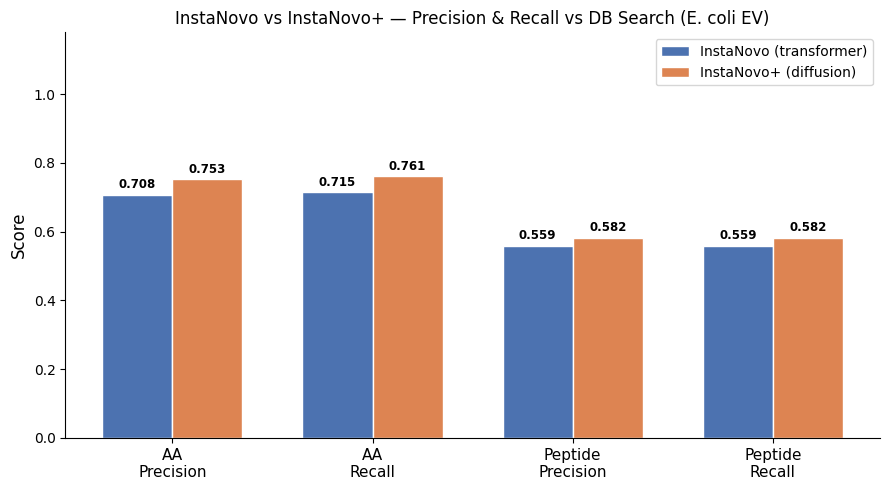

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# pick the two rows for E. coli EV
eco_in = summary_df[
    (summary_df["sample"] == "Ecoli_EV") &
    (summary_df["model"] == "instanovo_predictions_clean")
].iloc[0]

eco_ip = summary_df[
    (summary_df["sample"] == "Ecoli_EV") &
    (summary_df["model"] == "instanovoplus_predictions_clean")
].iloc[0]

# metric values
aa_prec_in  = eco_in["aa_precision"]
aa_rec_in   = eco_in["aa_recall"]
pep_prec_in = eco_in["peptide_precision"]
pep_rec_in  = eco_in["peptide_recall"]

aa_prec_ip  = eco_ip["aa_precision"]
aa_rec_ip   = eco_ip["aa_recall"]
pep_prec_ip = eco_ip["peptide_precision"]
pep_rec_ip  = eco_ip["peptide_recall"]

metric_labels = ['AA\nPrecision', 'AA\nRecall', 'Peptide\nPrecision', 'Peptide\nRecall']

inovo_vals  = [aa_prec_in, aa_rec_in, pep_prec_in, pep_rec_in]
inovoP_vals = [aa_prec_ip, aa_rec_ip, pep_prec_ip, pep_rec_ip]

x = np.arange(len(metric_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 5))

bars1 = ax.bar(
    x - width/2, inovo_vals, width,
    label='InstaNovo (transformer)',
    color='#4C72B0', edgecolor='white'
)

bars2 = ax.bar(
    x + width/2, inovoP_vals, width,
    label='InstaNovo+ (diffusion)',
    color='#DD8452', edgecolor='white'
)

for bar, val in list(zip(bars1, inovo_vals)) + list(zip(bars2, inovoP_vals)):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 0.01,
        f'{val:.3f}',
        ha='center',
        va='bottom',
        fontsize=8.5,
        fontweight='bold'
    )

ax.set_xticks(x)
ax.set_xticklabels(metric_labels, fontsize=11)
ax.set_ylim(0, 1.18)
ax.set_ylabel('Score', fontsize=12)
ax.set_title(
    'InstaNovo vs InstaNovo+ — Precision & Recall vs DB Search (E. coli EV)',
    fontsize=12
)

ax.legend(fontsize=10)
ax.spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.savefig('ecoli_instanovo_vs_instanovoplus.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
import numpy as np
import pandas as pd

def compute_empirical_fdr(details_df, score_col):
    df = details_df.copy()

    # keep rows with valid score + peptide match label
    df[score_col] = pd.to_numeric(df[score_col], errors="coerce")
    df = df.dropna(subset=[score_col, "peptide_match"]).copy()

    # sort best predictions first
    df = df.sort_values(score_col, ascending=False).reset_index(drop=True)

    # true/false discovery flags
    df["is_true"] = df["peptide_match"].astype(int)
    df["is_false"] = 1 - df["is_true"]

    # cumulative counts
    df["rank"] = np.arange(1, len(df) + 1)
    df["cum_true"] = df["is_true"].cumsum()
    df["cum_false"] = df["is_false"].cumsum()

    # empirical FDR at each rank
    df["fdr"] = df["cum_false"] / df["rank"]

    # q-value = best (lowest) FDR achievable at or above this score
    df["q_value"] = df["fdr"][::-1].cummin()[::-1]

    return df

In [ ]:
eco_in_fdr = compute_empirical_fdr(
    all_details["Ecoli_EV_instanovo"],
    "instanovo_prediction_log_probability"
)

eco_ip_fdr = compute_empirical_fdr(
    all_details["Ecoli_EV_instanovoplus"],
    "instanovoplus_prediction_log_probability"
)

display(eco_in_fdr.head())
display(eco_ip_fdr.head())

,fraction,scan_number,ground_truth_raw,ground_truth,pep,score,experiment_name,spectrum_id,precursor_mz,precursor_charge,...,gt_len,aa_matches,peptide_match,is_true,is_false,rank,cum_true,cum_false,fdr,q_value
0,Ecoli_EV_2,1856,_YPNNPGAK_,"[Y, P, N, N, P, G, A, K]",4.693000e-03,78.616,Ecoli_EV_2,Ecoli_EV_2:1856,430.71704,2,...,8,8,1,1,0,1,1,0,0.0,0.0
1,Ecoli_EV_2,10118,_QMIMVLAPK_,"[Q, M, I, M, V, L, A, P, K]",1.099800e-02,55.676,Ecoli_EV_2,Ecoli_EV_2:10118,515.79352,2,...,9,9,1,1,0,2,2,0,0.0,0.0
2,Ecoli_EV_1,6501,_DQFVQPVVK_,"[D, Q, F, V, Q, P, V, V, K]",7.738900e-04,96.190,Ecoli_EV_1,Ecoli_EV_1:6501,530.29559,2,...,9,9,1,1,0,3,3,0,0.0,0.0
3,Ecoli_EV_1,6119,_DQFVQPVVK_,"[D, Q, F, V, Q, P, V, V, K]",3.263900e-03,78.324,Ecoli_EV_1,Ecoli_EV_1:6119,530.29590,2,...,9,9,1,1,0,4,4,0,0.0,0.0
4,Ecoli_EV_2,2756,_HAVTEASPMVK_,"[H, A, V, T, E, A, S, P, M, V, K]",2.497500e-53,234.810,Ecoli_EV_2,Ecoli_EV_2:2756,585.30334,2,...,11,11,1,1,0,5,5,0,0.0,0.0


,fraction,scan_number,ground_truth_raw,ground_truth,pep,score,experiment_name,spectrum_id,precursor_mz,precursor_charge,...,gt_len,aa_matches,peptide_match,is_true,is_false,rank,cum_true,cum_false,fdr,q_value
0,Ecoli_EV_1,3033,_QDGSVDFGR_,"[Q, D, G, S, V, D, F, G, R]",3.736000e-13,157.330,Ecoli_EV_1,Ecoli_EV_1:3033,490.72552,2,...,9,9,1,1,0,1,1,0,0.0,0.0
1,Ecoli_EV_1,5444,_VATVSLPR_,"[V, A, T, V, S, L, P, R]",1.367100e-07,133.810,Ecoli_EV_1,Ecoli_EV_1:5444,421.75879,2,...,8,8,1,1,0,2,2,0,0.0,0.0
2,Ecoli_EV_1,3647,_DVVTQPQA_,"[D, V, V, T, Q, P, Q, A]",7.523900e-05,114.540,Ecoli_EV_1,Ecoli_EV_1:3647,429.22223,2,...,8,8,1,1,0,3,3,0,0.0,0.0
3,Ecoli_EV_2,3483,_YGYAYPR_,"[Y, G, Y, A, Y, P, R]",3.899300e-03,85.306,Ecoli_EV_2,Ecoli_EV_2:3483,445.21460,2,...,7,7,1,1,0,4,4,0,0.0,0.0
4,Ecoli_EV_2,6208,_FENMGAQMVK_,"[F, E, N, M, G, A, Q, M, V, K]",6.558300e-06,117.040,Ecoli_EV_2,Ecoli_EV_2:6208,577.77087,2,...,10,10,1,1,0,5,5,0,0.0,0.0


In [ ]:
def summarize_fdr(df, q_levels=(0.01, 0.05, 0.10)):
    rows = []
    for q in q_levels:
        keep = df[df["q_value"] <= q].copy()
        n = len(keep)

        rows.append({
            "q_threshold": q,
            "accepted_psms": n,
            "true_psms": int(keep["is_true"].sum()) if n > 0 else 0,
            "false_psms": int(keep["is_false"].sum()) if n > 0 else 0,
            "observed_fdr": (keep["is_false"].sum() / n) if n > 0 else np.nan,
            "peptide_precision": (keep["is_true"].mean()) if n > 0 else np.nan,
        })
    return pd.DataFrame(rows)

print("InstaNovo")
display(summarize_fdr(eco_in_fdr))

print("InstaNovo+")
display(summarize_fdr(eco_ip_fdr))

InstaNovo


,q_threshold,accepted_psms,true_psms,false_psms,observed_fdr,peptide_precision
0,0.01,40,40,0,0.000000,1.000000
1,0.05,409,389,20,0.048900,0.951100
2,0.10,1273,1146,127,0.099764,0.900236


InstaNovo+


,q_threshold,accepted_psms,true_psms,false_psms,observed_fdr,peptide_precision
0,0.01,34,34,0,0.000000,1.000000
1,0.05,91,87,4,0.043956,0.956044
2,0.10,1382,1244,138,0.099855,0.900145


In [ ]:
import os
import numpy as np
import pandas as pd

# folder in drive
ecoli_out = "/content/drive/MyDrive/Ecoli_FDR_Results"
os.makedirs(ecoli_out, exist_ok=True)

# save full ranked FDR tables
eco_in_fdr.to_csv(f"{ecoli_out}/ecoli_instanovo_ranked_fdr.csv", index=False)
eco_ip_fdr.to_csv(f"{ecoli_out}/ecoli_instanovoplus_ranked_fdr.csv", index=False)

# create summaries
eco_in_summary = summarize_fdr(eco_in_fdr)
eco_ip_summary = summarize_fdr(eco_ip_fdr)

# save summaries
eco_in_summary.to_csv(f"{ecoli_out}/ecoli_instanovo_fdr_summary.csv", index=False)
eco_ip_summary.to_csv(f"{ecoli_out}/ecoli_instanovoplus_fdr_summary.csv", index=False)

print("saved ranked FDR tables and summary tables to:")
print(ecoli_out)

display(eco_in_summary)
display(eco_ip_summary)

saved ranked FDR tables and summary tables to:
/content/drive/MyDrive/Ecoli_FDR_Results


,q_threshold,accepted_psms,true_psms,false_psms,observed_fdr,peptide_precision
0,0.01,40,40,0,0.000000,1.000000
1,0.05,409,389,20,0.048900,0.951100
2,0.10,1273,1146,127,0.099764,0.900236


,q_threshold,accepted_psms,true_psms,false_psms,observed_fdr,peptide_precision
0,0.01,34,34,0,0.000000,1.000000
1,0.05,91,87,4,0.043956,0.956044
2,0.10,1382,1244,138,0.099855,0.900145


In [ ]:
accepted_1_in = eco_in_fdr[eco_in_fdr["q_value"] <= 0.01].copy()
accepted_5_in = eco_in_fdr[eco_in_fdr["q_value"] <= 0.05].copy()
accepted_10_in = eco_in_fdr[eco_in_fdr["q_value"] <= 0.10].copy()

accepted_1_ip = eco_ip_fdr[eco_ip_fdr["q_value"] <= 0.01].copy()
accepted_5_ip = eco_ip_fdr[eco_ip_fdr["q_value"] <= 0.05].copy()
accepted_10_ip = eco_ip_fdr[eco_ip_fdr["q_value"] <= 0.10].copy()

accepted_1_in.to_csv(f"{ecoli_out}/ecoli_instanovo_targets_1pct_fdr.csv", index=False)
accepted_5_in.to_csv(f"{ecoli_out}/ecoli_instanovo_targets_5pct_fdr.csv", index=False)
accepted_10_in.to_csv(f"{ecoli_out}/ecoli_instanovo_targets_10pct_fdr.csv", index=False)

accepted_1_ip.to_csv(f"{ecoli_out}/ecoli_instanovoplus_targets_1pct_fdr.csv", index=False)
accepted_5_ip.to_csv(f"{ecoli_out}/ecoli_instanovoplus_targets_5pct_fdr.csv", index=False)
accepted_10_ip.to_csv(f"{ecoli_out}/ecoli_instanovoplus_targets_10pct_fdr.csv", index=False)

print("saved accepted PSM files at 1%, 5%, and 10% FDR")

saved accepted PSM files at 1%, 5%, and 10% FDR


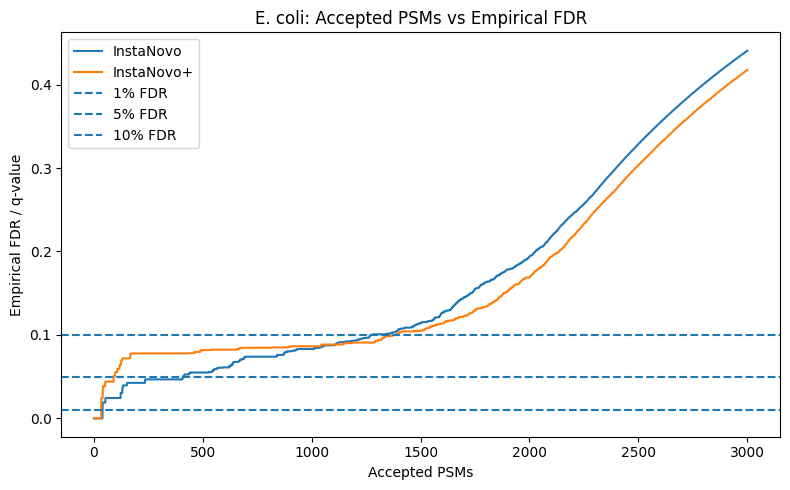

In [ ]:
import matplotlib.pyplot as plt

plot_dir = f"{ecoli_out}/plots"
os.makedirs(plot_dir, exist_ok=True)

plt.figure(figsize=(8, 5))
plt.plot(eco_in_fdr["rank"], eco_in_fdr["q_value"], label="InstaNovo")
plt.plot(eco_ip_fdr["rank"], eco_ip_fdr["q_value"], label="InstaNovo+")
plt.axhline(0.01, linestyle="--", label="1% FDR")
plt.axhline(0.05, linestyle="--", label="5% FDR")
plt.axhline(0.10, linestyle="--", label="10% FDR")
plt.xlabel("Accepted PSMs")
plt.ylabel("Empirical FDR / q-value")
plt.title("E. coli: Accepted PSMs vs Empirical FDR")
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/ecoli_accepted_psms_vs_empirical_fdr.png", dpi=300)
plt.show()

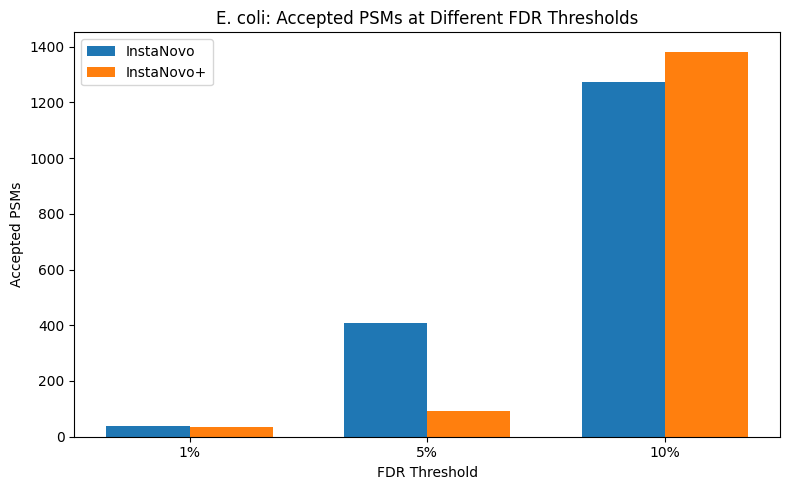

In [ ]:
bar_df = pd.DataFrame({
    "FDR": ["1%", "5%", "10%"],
    "InstaNovo": eco_in_summary["accepted_psms"].values,
    "InstaNovoPlus": eco_ip_summary["accepted_psms"].values
})

x = np.arange(len(bar_df))
width = 0.35

plt.figure(figsize=(8, 5))
plt.bar(x - width/2, bar_df["InstaNovo"], width, label="InstaNovo")
plt.bar(x + width/2, bar_df["InstaNovoPlus"], width, label="InstaNovo+")
plt.xticks(x, bar_df["FDR"])
plt.xlabel("FDR Threshold")
plt.ylabel("Accepted PSMs")
plt.title("E. coli: Accepted PSMs at Different FDR Thresholds")
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/ecoli_barplot_accepted_psms.png", dpi=300)
plt.show()

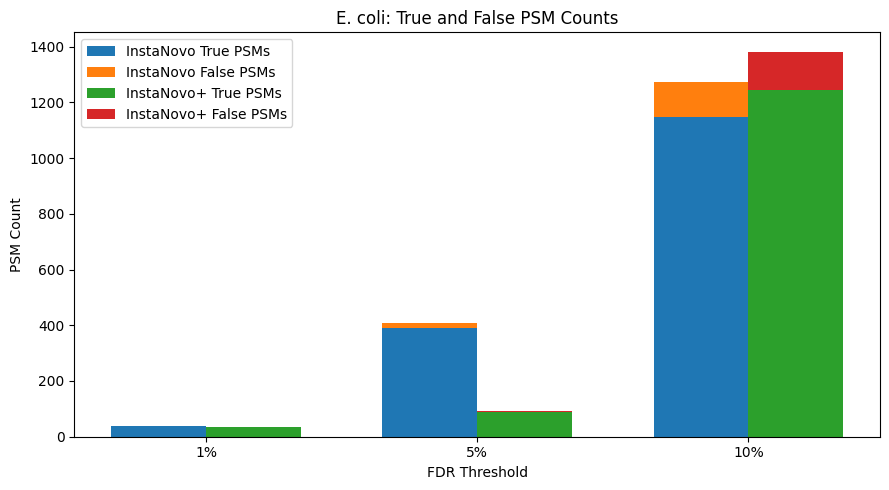

In [ ]:
x = np.arange(len(eco_in_summary))
width = 0.35

plt.figure(figsize=(9, 5))
plt.bar(x - width/2, eco_in_summary["true_psms"], width, label="InstaNovo True PSMs")
plt.bar(x - width/2, eco_in_summary["false_psms"], width, bottom=eco_in_summary["true_psms"], label="InstaNovo False PSMs")

plt.bar(x + width/2, eco_ip_summary["true_psms"], width, label="InstaNovo+ True PSMs")
plt.bar(x + width/2, eco_ip_summary["false_psms"], width, bottom=eco_ip_summary["true_psms"], label="InstaNovo+ False PSMs")

plt.xticks(x, ["1%", "5%", "10%"])
plt.xlabel("FDR Threshold")
plt.ylabel("PSM Count")
plt.title("E. coli: True and False PSM Counts")
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/ecoli_true_false_psm_counts.png", dpi=300)
plt.show()

In [ ]:
!ls -lh "/content/drive/MyDrive/Ecoli_FDR_Results"
!ls -lh "/content/drive/MyDrive/Ecoli_FDR_Results/plots"

total 24M
-rw------- 1 root root  209 May  4 02:10 ecoli_instanovo_fdr_summary.csv
-rw------- 1 root root  208 May  4 02:10 ecoli_instanovoplus_fdr_summary.csv
-rw------- 1 root root 8.0M May  4 02:10 ecoli_instanovoplus_ranked_fdr.csv
-rw------- 1 root root 3.1M May  4 02:10 ecoli_instanovoplus_targets_10pct_fdr.csv
-rw------- 1 root root  69K May  4 02:10 ecoli_instanovoplus_targets_1pct_fdr.csv
-rw------- 1 root root 196K May  4 02:10 ecoli_instanovoplus_targets_5pct_fdr.csv
-rw------- 1 root root 8.0M May  4 02:10 ecoli_instanovo_ranked_fdr.csv
-rw------- 1 root root 2.9M May  4 02:10 ecoli_instanovo_targets_10pct_fdr.csv
-rw------- 1 root root  81K May  4 02:10 ecoli_instanovo_targets_1pct_fdr.csv
-rw------- 1 root root 911K May  4 02:10 ecoli_instanovo_targets_5pct_fdr.csv
drwx------ 2 root root 4.0K May  4 02:12 plots
total 350K
-rw------- 1 root root 147K May  4 02:11 ecoli_accepted_psms_vs_empirical_fdr.png
-rw------- 1 root root  93K May  4 02:11 ecoli_barplot_accepted_psms.p

In [ ]:
comparison_df = pd.DataFrame({
    "FDR": ["1%", "5%", "10%"],
    "InstaNovo_Accepted_PSMs": eco_in_summary["accepted_psms"].values,
    "InstaNovo_True_PSMs": eco_in_summary["true_psms"].values,
    "InstaNovo_False_PSMs": eco_in_summary["false_psms"].values,
    "InstaNovo_Observed_FDR": eco_in_summary["observed_fdr"].values,
    "InstaNovoPlus_Accepted_PSMs": eco_ip_summary["accepted_psms"].values,
    "InstaNovoPlus_True_PSMs": eco_ip_summary["true_psms"].values,
    "InstaNovoPlus_False_PSMs": eco_ip_summary["false_psms"].values,
    "InstaNovoPlus_Observed_FDR": eco_ip_summary["observed_fdr"].values
})

comparison_df.to_csv(f"{ecoli_out}/ecoli_instanovo_vs_instanovoplus_fdr_comparison.csv", index=False)
display(comparison_df)

,FDR,InstaNovo_Accepted_PSMs,InstaNovo_True_PSMs,InstaNovo_False_PSMs,InstaNovo_Observed_FDR,InstaNovoPlus_Accepted_PSMs,InstaNovoPlus_True_PSMs,InstaNovoPlus_False_PSMs,InstaNovoPlus_Observed_FDR
0,1%,40,40,0,0.000000,34,34,0,0.000000
1,5%,409,389,20,0.048900,91,87,4,0.043956
2,10%,1273,1146,127,0.099764,1382,1244,138,0.099855


## Instanovo and Instanovo plus prediction for Wasterwater samples

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML" --output-path instanovo_waste1_preds1.csv


[04/27/26 21:28:01] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/27/26 21:28:04] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-27 21:28:09.999031: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-27 21:28:10.018139: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777325290.040738    1633 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mzML" --output-path instanovo_waste1_preds2.csv



[04/28/26 00:36:13] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/28/26 00:36:17] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-28 00:36:22.611095: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 00:36:22.629592: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777336582.652368    2816 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mzML" --output-path instanovo_waste2_preds1.csv


[04/28/26 01:03:54] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/28/26 01:03:57] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-28 01:04:00.082738: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 01:04:00.101984: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777338240.124783   10002 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
!instanovo predict --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mzML" --output-path instanovo_waste2_preds2.csv

[04/28/26 01:28:19] INFO     Initializing InstaNovo inference.                                                                                                                 
[04/28/26 01:28:21] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-04-28 01:28:24.270521: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-28 01:28:24.292328: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1777339704.315701   16361 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when o

In [ ]:
import pandas as pd

files = [
    "instanovo_waste1_preds1.csv",
    "instanovo_waste1_preds2.csv",
    "instanovo_waste2_preds1.csv",
    "instanovo_waste2_preds2.csv",
]

for f in files:
    df = pd.read_csv(f)
    print("\n", "="*80)
    print(f)
    print("shape:", df.shape)
    print("columns:", df.columns.tolist())
    display(df.head(2))


instanovo_waste1_preds1.csv
shape: (17100, 34)
columns: ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictions_token_log_probabilities_

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,instanovo_predictions_token_log_probabilities_beam_3,instanovo_predictions_beam_4,instanovo_predictions_log_probability_beam_4,instanovo_predictions_token_log_probabilities_beam_4,instanovoplus_predictions,instanovoplus_prediction_log_probability,instanovoplus_prediction_token_log_probabilities,instanovoplus_unrefined_predictions,predictions_tokenised,delta_mass_ppm
0,wastewater_Sample1_1,40,wastewater_Sample1_1:40,741.19696,2,0,GAEDSES[UNIMOD:21]DENS[UNIMOD:21]PK,-1.584579,NaN,no_group,...,"[-4.7865400314331055, -1.1052268743515015, -0....",GPEPSEVDMNS[UNIMOD:21]PK,-21.543739,"[-5.070550441741943, -1.0036643743515015, -0.0...","['G', 'A', 'E', 'D', 'S', 'E', 'S[UNIMOD:21]',...",-1.584579,NaN,"['G', 'A', 'E', 'P', 'S', 'E', 'V', 'D', 'M', ...","G, A, E, D, S, E, S[UNIMOD:21], D, E, N, S[UNI...",29067.990916
1,wastewater_Sample1_1,166,wastewater_Sample1_1:166,684.20398,2,1,PSTSTTPDQILR,-1.596870,NaN,no_group,...,"[-1.7887654304504395, -1.1247025728225708, -0....",AGSTPTPPLS[UNIMOD:21]PVR,-12.533523,"[-3.0845017433166504, -1.3874346017837524, -0....","['P', 'S', 'T', 'S', 'T', 'T', 'P', 'D', 'Q', ...",-1.596870,NaN,"['P', 'S', 'T', 'P', 'T', 'L', 'P', 'L', 'S[UN...","P, S, T, S, T, T, P, D, Q, I, L, R",37059.199802



instanovo_waste1_preds2.csv
shape: (17600, 34)
columns: ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictions_token_log_probabilities_

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,instanovo_predictions_token_log_probabilities_beam_3,instanovo_predictions_beam_4,instanovo_predictions_log_probability_beam_4,instanovo_predictions_token_log_probabilities_beam_4,instanovoplus_predictions,instanovoplus_prediction_log_probability,instanovoplus_prediction_token_log_probabilities,instanovoplus_unrefined_predictions,predictions_tokenised,delta_mass_ppm
0,wastewater_Sample1_2,17,wastewater_Sample1_2:17,459.17255,3,0,ERS[UNIMOD:21]MEEEEEK,-1.349083,NaN,no_group,...,"[-0.0003935516288038343, -0.008713793940842152...",EVGS[UNIMOD:21]DEEEEKK,-26.113327,"[-9.599026679992676, -0.008713793940842152, -0...","['E', 'R', 'S[UNIMOD:21]', 'M', 'E', 'E', 'E',...",-1.349083,NaN,"['K', 'N', 'S[UNIMOD:21]', 'E', 'E', 'E', 'E',...","E, R, S[UNIMOD:21], M, E, E, E, E, E, K",3.573820
1,wastewater_Sample1_2,35,wastewater_Sample1_2:35,454.86768,2,1,M[UNIMOD:35]IEELQR,-0.807845,NaN,no_group,...,"[-2.3782448768615723, -2.296055793762207, -1.7...",YGAEALER,-19.021355,"[-1.4022635221481323, -0.5499619245529175, -1....","['M[UNIMOD:35]', 'I', 'E', 'E', 'L', 'Q', 'R']",-0.807845,NaN,"['E', 'K', 'E', 'A', 'L', 'E', 'R']","M[UNIMOD:35], I, E, E, L, Q, R",28291.958444



instanovo_waste2_preds1.csv
shape: (16144, 34)
columns: ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictions_token_log_probabilities_

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,instanovo_predictions_token_log_probabilities_beam_3,instanovo_predictions_beam_4,instanovo_predictions_log_probability_beam_4,instanovo_predictions_token_log_probabilities_beam_4,instanovoplus_predictions,instanovoplus_prediction_log_probability,instanovoplus_prediction_token_log_probabilities,instanovoplus_unrefined_predictions,predictions_tokenised,delta_mass_ppm
0,wastewater_Sample2_1,40,wastewater_Sample2_1:40,453.75632,2,0,NKPGVYTK,-0.000630,NaN,no_group,...,"[-2.0414581298828125, -4.824115753173828, -1.3...",VEPGVYTK,-11.254655,"[-1.088606834411621, -5.536029815673828, -1.31...","['N', 'K', 'P', 'G', 'V', 'Y', 'T', 'K']",-0.000630,NaN,"['N', 'K', 'P', 'G', 'V', 'Y', 'T', 'K']","N, K, P, G, V, Y, T, K",1.095302
1,wastewater_Sample2_1,59,wastewater_Sample2_1:59,425.21533,2,1,NKS[UNIMOD:21]PPVK,-0.652401,NaN,no_group,...,"[-1.294806957244873, -0.5492164492607117, -0.4...",PPPS[UNIMOD:21]PPR,-13.647928,"[-1.7221434116363525, -0.6688963174819946, -0....","['N', 'K', 'S[UNIMOD:21]', 'P', 'P', 'V', 'K']",-0.652401,NaN,"['S[UNIMOD:21]', 'K', 'S[UNIMOD:21]', 'P', 'P'...","N, K, S[UNIMOD:21], P, P, V, K",0.805474



instanovo_waste2_preds2.csv
shape: (10306, 34)
columns: ['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictions_token_log_probabilities_

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction_id,predictions,log_probs,token_log_probs,group,...,instanovo_predictions_token_log_probabilities_beam_3,instanovo_predictions_beam_4,instanovo_predictions_log_probability_beam_4,instanovo_predictions_token_log_probabilities_beam_4,instanovoplus_predictions,instanovoplus_prediction_log_probability,instanovoplus_prediction_token_log_probabilities,instanovoplus_unrefined_predictions,predictions_tokenised,delta_mass_ppm
0,wastewater_Sample2_2,16,wastewater_Sample2_2:16,449.58127,3,0,WEKLEEEKKK,-0.731085,NaN,no_group,...,"[-6.321409702301025, -0.894237756729126, -0.60...",AGS[UNIMOD:21]DEEEEEKK,-23.022530,"[-6.417112827301025, -0.894237756729126, -0.60...","['W', 'E', 'K', 'L', 'E', 'E', 'E', 'K', 'K', ...",-0.731085,NaN,"['S[UNIMOD:21]', 'E', 'E', 'E', 'E', 'E', 'E',...","W, E, K, L, E, E, E, K, K, K",1.645235
1,wastewater_Sample2_2,17,wastewater_Sample2_2:17,459.17291,3,1,MRS[UNIMOD:21]EEEEEEK,-1.912826,NaN,no_group,...,"[-9.929640509653836e-05, -3.611976353568025e-0...",EVGS[UNIMOD:21]DEEEEKK,-26.212597,"[-9.981884002685547, -0.007127927616238594, -0...","['M', 'R', 'S[UNIMOD:21]', 'E', 'E', 'E', 'E',...",-1.912826,NaN,"['K', 'N', 'S[UNIMOD:21]', 'E', 'E', 'E', 'E',...","M, R, S[UNIMOD:21], E, E, E, E, E, E, K",2.789799


In [ ]:
import pandas as pd
from pathlib import Path

def prepare_for_novoboard(csv_path, model="instanovo"):
    df = pd.read_csv(csv_path)

    base_cols = ["experiment_name", "scan_number", "spectrum_id", "precursor_mz", "precursor_charge"]

    if model == "instanovo":
        out = df[base_cols].copy()
        out["prediction"] = df["instanovo_predictions"]
        out["score"] = df["instanovo_prediction_log_probability"]

        for i in range(5):
            pred_col = f"instanovo_predictions_beam_{i}"
            score_col = f"instanovo_predictions_log_probability_beam_{i}"
            if pred_col in df.columns:
                out[f"beam_{i}_prediction"] = df[pred_col]
            if score_col in df.columns:
                out[f"beam_{i}_score"] = df[score_col]

    elif model == "instanovoplus":
        out = df[base_cols].copy()
        out["prediction"] = df["instanovoplus_predictions"]
        out["score"] = df["instanovoplus_prediction_log_probability"]

    else:
        raise ValueError("model must be 'instanovo' or 'instanovoplus'")

    # useful helper columns
    if "delta_mass_ppm" in df.columns:
        out["delta_mass_ppm"] = df["delta_mass_ppm"]

    return out


files = [
    "instanovo_waste1_preds1.csv",
    "instanovo_waste1_preds2.csv",
    "instanovo_waste2_preds1.csv",
    "instanovo_waste2_preds2.csv",
]

for f in files:
    stem = Path(f).stem

    ino = prepare_for_novoboard(f, model="instanovo")
    ino_path = f"{stem}_novoboard_instanovo.csv"
    ino.to_csv(ino_path, index=False)

    inp = prepare_for_novoboard(f, model="instanovoplus")
    inp_path = f"{stem}_novoboard_instanovoplus.csv"
    inp.to_csv(inp_path, index=False)

    print("saved:", ino_path, ino.shape)
    print("saved:", inp_path, inp.shape)

saved: instanovo_waste1_preds1_novoboard_instanovo.csv (17100, 18)
saved: instanovo_waste1_preds1_novoboard_instanovoplus.csv (17100, 8)
saved: instanovo_waste1_preds2_novoboard_instanovo.csv (17600, 18)
saved: instanovo_waste1_preds2_novoboard_instanovoplus.csv (17600, 8)
saved: instanovo_waste2_preds1_novoboard_instanovo.csv (16144, 18)
saved: instanovo_waste2_preds1_novoboard_instanovoplus.csv (16144, 8)
saved: instanovo_waste2_preds2_novoboard_instanovo.csv (10306, 18)
saved: instanovo_waste2_preds2_novoboard_instanovoplus.csv (10306, 8)


In [ ]:
df_check = pd.read_csv("instanovo_waste1_preds1_novoboard_instanovo.csv")
display(df_check.head())
print(df_check.columns.tolist())

,experiment_name,scan_number,spectrum_id,precursor_mz,precursor_charge,prediction,score,beam_0_prediction,beam_0_score,beam_1_prediction,beam_1_score,beam_2_prediction,beam_2_score,beam_3_prediction,beam_3_score,beam_4_prediction,beam_4_score,delta_mass_ppm
0,wastewater_Sample1_1,40,wastewater_Sample1_1:40,741.19696,2,"['G', 'A', 'E', 'P', 'S', 'E', 'V', 'D', 'M', ...",-16.357475,GAEPSEVDMNS[UNIMOD:21]PK,-16.357475,AAEPSEVDMNS[UNIMOD:21]PK,-16.503107,PAEPSEVDMNS[UNIMOD:21]PK,-18.089354,SAEPSEVDMNS[UNIMOD:21]PK,-20.275141,GPEPSEVDMNS[UNIMOD:21]PK,-21.543739,29067.990916
1,wastewater_Sample1_1,166,wastewater_Sample1_1:166,684.20398,2,"['P', 'S', 'T', 'P', 'T', 'L', 'P', 'L', 'S[UN...",-9.520633,PSTPTLPLS[UNIMOD:21]PVR,-9.520633,TSTPTLPLS[UNIMOD:21]PVR,-9.818792,AGSSPSLPLS[UNIMOD:21]PVR,-11.888061,GSSSPSLPLS[UNIMOD:21]PVR,-12.176419,AGSTPTPPLS[UNIMOD:21]PVR,-12.533523,37059.199802
2,wastewater_Sample1_1,257,wastewater_Sample1_1:257,758.22266,2,"['E', 'E', 'D', 'D', 'A', 'P', 'V', 'L', 'P', ...",-11.388241,EEDDAPVLPS[UNIMOD:21]PLK,-11.388241,MEEPAPVLPS[UNIMOD:21]PLK,-11.741720,SGEDDAPVLPS[UNIMOD:21]PLK,-14.938802,GGEDDAPVLPS[UNIMOD:21]PLK,-15.044438,PGEDDAPVLPS[UNIMOD:21]PLK,-18.564556,25629.053344
3,wastewater_Sample1_1,398,wastewater_Sample1_1:398,624.23682,2,"['S[UNIMOD:21]', 'E', 'E', 'E', 'E', 'E', 'E',...",-11.058372,S[UNIMOD:21]EEEEEEEK,-11.058372,NS[UNIMOD:21]EEEEEEK,-12.072778,QS[UNIMOD:21]EEEEEEK,-16.412472,GEEEEEEEEK,-19.578773,DVGS[UNIMOD:21]DEEEEK,-21.400703,24030.644331
4,wastewater_Sample1_1,408,wastewater_Sample1_1:408,698.25641,2,"['S[UNIMOD:21]', 'E', 'E', 'E', 'E', 'E', 'E',...",-13.593733,S[UNIMOD:21]EEEEEEEEK,-13.593733,GKNS[UNIMOD:21]EEEEEEK,-16.879951,GNS[UNIMOD:21]EEEEEEEK,-17.684807,QS[UNIMOD:21]EEEEEEEK,-18.690422,EDVGS[UNIMOD:21]DEEEEK,-20.007469,61586.271725


['experiment_name', 'scan_number', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction', 'score', 'beam_0_prediction', 'beam_0_score', 'beam_1_prediction', 'beam_1_score', 'beam_2_prediction', 'beam_2_score', 'beam_3_prediction', 'beam_3_score', 'beam_4_prediction', 'beam_4_score', 'delta_mass_ppm']


In [ ]:
wastewater_pairs = [
    {
        "mzml": "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML",
        "instanovo_csv": "/content/instanovo_waste1_preds1_novoboard_instanovo.csv",
        "instanovoplus_csv": "/content/instanovo_waste1_preds1_novoboard_instanovoplus.csv",
        "name": "wastewater_Sample1_1",
    },
    {
        "mzml": "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mzML",
        "instanovo_csv": "/content/instanovo_waste1_preds2_novoboard_instanovo.csv",
        "instanovoplus_csv": "/content/instanovo_waste1_preds2_novoboard_instanovoplus.csv",
        "name": "wastewater_Sample1_2",
    },
    {
        "mzml": "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mzML",
        "instanovo_csv": "/content/instanovo_waste2_preds1_novoboard_instanovo.csv",
        "instanovoplus_csv": "/content/instanovo_waste2_preds1_novoboard_instanovoplus.csv",
        "name": "wastewater_Sample2_1",
    },
    {
        "mzml": "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mzML",
        "instanovo_csv": "/content/instanovo_waste2_preds2_novoboard_instanovo.csv",
        "instanovoplus_csv": "/content/instanovo_waste2_preds2_novoboard_instanovoplus.csv",
        "name": "wastewater_Sample2_2",
    },
]

In [ ]:
import pandas as pd

def make_novoboard_fdr_csv(input_csv, output_csv, model="instanovo"):
    df = pd.read_csv(input_csv)

    if model == "instanovo":
        pep_col = "instanovo_predictions"
        score_col = "instanovo_prediction_log_probability"
    elif model == "instanovoplus":
        pep_col = "instanovoplus_predictions"
        score_col = "instanovoplus_prediction_log_probability"
    else:
        raise ValueError("model must be 'instanovo' or 'instanovoplus'")

    out = pd.DataFrame({
        "Source File": df["experiment_name"].astype(str) + ".mgf",
        "Scan": df["scan_number"].astype(str),
        "Peptide": df[pep_col].astype(str),
        "Score": pd.to_numeric(df[score_col], errors="coerce"),
    })

    out = out.dropna(subset=["Score"]).copy()
    out.to_csv(output_csv, index=False)
    print("saved:", output_csv, out.shape)


In [ ]:

make_novoboard_fdr_csv("instanovo_waste1_preds1.csv", "waste1_1_target_instanovo_fdr.csv", model="instanovo")
make_novoboard_fdr_csv("instanovo_waste1_preds2.csv", "waste1_2_target_instanovo_fdr.csv", model="instanovo")
make_novoboard_fdr_csv("instanovo_waste2_preds1.csv", "waste2_1_target_instanovo_fdr.csv", model="instanovo")
make_novoboard_fdr_csv("instanovo_waste2_preds2.csv", "waste2_2_target_instanovo_fdr.csv", model="instanovo")

In [ ]:
!find /content/drive/MyDrive/Wastewater -maxdepth 1 \( -name "*.mgf" -o -name "*.mzML" \)

/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML
/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mzML
/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mzML
/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mzML


In [ ]:
!pip install -q pyteomics lxml

In [ ]:
import re
from pyteomics import mzml, mgf

def mzml_to_mgf(mzml_path, mgf_path):
    spectra_out = []
    written = 0

    with mzml.read(mzml_path) as reader:
        for i, spec in enumerate(reader):
            if int(spec.get("ms level", 1)) != 2:
                continue

            mz_array = spec.get("m/z array")
            intensity_array = spec.get("intensity array")
            if mz_array is None or intensity_array is None or len(mz_array) == 0:
                continue

            spec_id = str(spec.get("id", f"scan={i+1}"))

            m = re.search(r"scan=(\d+)", spec_id)
            scan_num = m.group(1) if m else str(i + 1)

            pepmass = None
            charge = None
            try:
                precursor = spec["precursorList"]["precursor"][0]
                selected_ion = precursor["selectedIonList"]["selectedIon"][0]
                pepmass = selected_ion.get("selected ion m/z")
                charge = selected_ion.get("charge state")
            except Exception:
                pass

            params = {
                "title": spec_id,
                "scans": scan_num,
            }
            if pepmass is not None:
                params["pepmass"] = (float(pepmass),)
            if charge is not None:
                params["charge"] = [f"{int(charge)}+"]

            spectra_out.append({
                "m/z array": mz_array,
                "intensity array": intensity_array,
                "params": params
            })
            written += 1

    with open(mgf_path, "w") as out_handle:
        mgf.write(spectra_out, output=out_handle)

    print(f"saved: {mgf_path}  |  MS2 spectra written: {written}")

In [ ]:
mzml_to_mgf(
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mzML",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf"
)

mzml_to_mgf(
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mzML",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf"
)

mzml_to_mgf(
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mzML",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf"
)

mzml_to_mgf(
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mzML",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf"
)

saved: /content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf  |  MS2 spectra written: 17100
saved: /content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf  |  MS2 spectra written: 17600
saved: /content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf  |  MS2 spectra written: 16144
saved: /content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf  |  MS2 spectra written: 10306


In [ ]:
import re
import random
import numpy as np

input_mgf_list = [
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf",
    "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf",
]

peak_sampling = "random"
sampling_rate = 0.5

for input_mgf in input_mgf_list:
    output_mgf = input_mgf + ".decoy_{0:.2f}.mgf".format(sampling_rate)

    peaks_distr = [
        [float(x) for x in re.split(' |\r|\n', line)[:2]]
        for line in open(input_mgf, 'r')
        if line and line[0].isdigit()
    ]

    with open(input_mgf, 'r') as f_in:
        with open(output_mgf, 'w') as f_out:
            while True:
                line = f_in.readline()
                if not line:
                    break
                if line == '\n':
                    continue

                peak_list = []
                while "END IONS" not in line:
                    if 'BEGIN IONS' in line or '=' in line:
                        f_out.write(line)
                        line = f_in.readline()
                        continue

                    mz, intensity = re.split(' |\r|\n', line)[:2]
                    peak_list.append([float(mz), float(intensity)])
                    line = f_in.readline()

                num_peaks = len(peak_list)
                num_sampling = int(num_peaks * sampling_rate)
                num_noise = num_peaks - num_sampling

                random.seed(99)
                np.random.seed(99)

                sampling_peaks = random.sample(peak_list, num_sampling)
                noise_peaks = random.sample(peaks_distr, num_noise)

                sorted_peaks = sorted(sampling_peaks + noise_peaks, key=lambda x: x[0])
                for x, y in sorted_peaks:
                    f_out.write("{0:.5f} {1:.5f}\n".format(x, y))

                f_out.write(line)
                f_out.write(f_in.readline())

    print("saved decoy:", output_mgf)

saved decoy: /content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf.decoy_0.50.mgf
saved decoy: /content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf.decoy_0.50.mgf
saved decoy: /content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf.decoy_0.50.mgf
saved decoy: /content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf.decoy_0.50.mgf


In [ ]:
!find /content/drive/MyDrive/Wastewater -maxdepth 1 -name "*.decoy_0.50.mgf"

/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf.decoy_0.50.mgf
/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf.decoy_0.50.mgf
/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf.decoy_0.50.mgf
/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf.decoy_0.50.mgf


In [ ]:
!mkdir -p "/content/drive/MyDrive/Wastewater/decoy_csv_outputs"

In [ ]:
!pip uninstall -y instanovo torch torchvision torchaudio

Found existing installation: instanovo 1.2.2
Uninstalling instanovo-1.2.2:
  Successfully uninstalled instanovo-1.2.2
Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128


In [ ]:
!pip install --no-cache-dir \
  --index-url https://download.pytorch.org/whl/cu126 \
  torch==2.8.0 torchvision torchaudio

Looking in indexes: https://download.pytorch.org/whl/cu126


In [ ]:
!pip install --no-cache-dir instanovo

In [ ]:
import torch, instanovo
print("torch:", torch.__version__)
print("cuda available:", torch.cuda.is_available())

torch: 2.8.0+cu126
cuda available: True


In [ ]:

!instanovo predict \
  --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample1_1.mgf.decoy_0.50.mgf" \
  --output-path "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds1_decoy.csv"


[05/03/26 23:54:35] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/03/26 23:54:37] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-03 23:54:40.235967: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-03 23:54:40.301863: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-03 23:54

In [ ]:

!instanovo predict \
  --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample1_2.mgf.decoy_0.50.mgf" \
  --output-path "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds2_decoy.csv"


[05/04/26 00:21:44] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/04/26 00:21:46] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-04 00:21:48.951384: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 00:21:49.016844: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-04 00:21

In [ ]:

!instanovo predict \
  --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample2_1.mgf.decoy_0.50.mgf" \
  --output-path "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds1_decoy.csv"


[05/04/26 00:48:42] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/04/26 00:48:44] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-04 00:48:47.102188: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 00:48:47.166905: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-04 00:48

In [ ]:

!instanovo predict \
  --data-path "/content/drive/MyDrive/Wastewater/wastewater_Sample2_2.mgf.decoy_0.50.mgf" \
  --output-path "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds2_decoy.csv"

[05/04/26 01:13:15] INFO     Initializing InstaNovo inference.                                                                                                                 
[05/04/26 01:13:18] INFO     NumExpr defaulting to 12 threads.                                                                                                                 
2026-05-04 01:13:20.832038: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-05-04 01:13:20.898222: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
DEBUG:2026-05-04 01:13

In [ ]:
!ls -lh "/content/drive/MyDrive/Wastewater/decoy_csv_outputs"

total 141M
-rw------- 1 root root 39M May  4 00:21 instanovo_waste1_preds1_decoy.csv
-rw------- 1 root root 41M May  4 00:48 instanovo_waste1_preds2_decoy.csv
-rw------- 1 root root 38M May  4 01:13 instanovo_waste2_preds1_decoy.csv
-rw------- 1 root root 24M May  4 01:28 instanovo_waste2_preds2_decoy.csv


In [ ]:
make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds1_decoy.csv",
    "waste1_1_decoy_instanovo_fdr.csv",
    model="instanovo"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds2_decoy.csv",
    "waste1_2_decoy_instanovo_fdr.csv",
    model="instanovo"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds1_decoy.csv",
    "waste2_1_decoy_instanovo_fdr.csv",
    model="instanovo"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds2_decoy.csv",
    "waste2_2_decoy_instanovo_fdr.csv",
    model="instanovo"
)

saved: waste1_1_decoy_instanovo_fdr.csv (17100, 4)
saved: waste1_2_decoy_instanovo_fdr.csv (17600, 4)
saved: waste2_1_decoy_instanovo_fdr.csv (16144, 4)
saved: waste2_2_decoy_instanovo_fdr.csv (10306, 4)


In [ ]:
import pandas as pd
import numpy as np

def read_denovo(denovo_csv, selected_features=None):
    denovo_psm = pd.read_csv(denovo_csv, keep_default_na=False)
    denovo_psm["feature_id"] = denovo_psm.apply(
        lambda row: str(row["Source File"]).split(".mgf")[0] + ".mgf" + "||" + str(row["Scan"]),
        axis=1
    )
    if selected_features is not None:
        denovo_psm = denovo_psm[denovo_psm["feature_id"].isin(selected_features)].copy()
    return denovo_psm

def calculate_FDR(target_csv, decoy_csv, engine_score="Score", fdr_list=[0.01, 0.05, 0.10], selected_features=None):
    target_psm = read_denovo(target_csv, selected_features)
    decoy_psm = read_denovo(decoy_csv, selected_features)

    dfs = pd.concat([target_psm, decoy_psm], keys=["target", "decoy"]).reset_index()
    dfs = dfs.rename(columns={"level_0": "spectrum"})
    dfs["is_target"] = dfs["spectrum"] == "target"

    dfs = dfs.sort_values(by=[engine_score, "is_target"], ascending=[False, False]).copy()
    dfs["feature_id"] = dfs.apply(
        lambda x: x["feature_id"] if x["is_target"] else x["feature_id"] + "||decoy",
        axis=1
    )

    cumsum = np.arange(1, len(dfs) + 1)
    cumsum_target = np.cumsum(dfs["is_target"].astype(int).values)
    cumsum_decoy = cumsum - cumsum_target

    with np.errstate(divide="ignore", invalid="ignore"):
        dfs["estimated_fdr"] = np.where(cumsum_target > 0, cumsum_decoy / cumsum_target, np.inf)

    summary_rows = []
    for fdr in fdr_list:
        idx = np.flatnonzero(dfs["estimated_fdr"].values <= fdr)
        if len(idx) == 0:
            summary_rows.append({
                "fdr_threshold": fdr,
                "score_cutoff": None,
                "accepted_psms_total": 0,
                "accepted_target_psms": 0
            })
        else:
            last = idx[-1]
            accepted = dfs.iloc[:last+1]
            accepted_target = accepted[accepted["is_target"]]
            summary_rows.append({
                "fdr_threshold": fdr,
                "score_cutoff": accepted.iloc[-1][engine_score],
                "accepted_psms_total": len(accepted),
                "accepted_target_psms": len(accepted_target)
            })

    summary_df = pd.DataFrame(summary_rows)
    return dfs, summary_df

In [ ]:
dfs_fdr_11, summary_11 = calculate_FDR(
    "waste1_1_target_instanovo_fdr.csv",
    "waste1_1_decoy_instanovo_fdr.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_12, summary_12 = calculate_FDR(
    "waste1_2_target_instanovo_fdr.csv",
    "waste1_2_decoy_instanovo_fdr.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_21, summary_21 = calculate_FDR(
    "waste2_1_target_instanovo_fdr.csv",
    "waste2_1_decoy_instanovo_fdr.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_22, summary_22 = calculate_FDR(
    "waste2_2_target_instanovo_fdr.csv",
    "waste2_2_decoy_instanovo_fdr.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

display(summary_11)
display(summary_12)
display(summary_21)
display(summary_22)

,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.052251,3021,2992
1,0.05,-0.871161,7131,6792
2,0.10,-1.939104,8881,8074


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.018970,1936,1917
1,0.05,-0.877469,7667,7302
2,0.10,-2.197285,9896,8997


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.014071,1385,1372
1,0.05,-0.832337,6011,5725
2,0.10,-2.039606,7867,7152


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.066036,1516,1501
1,0.05,-0.847918,3957,3769
2,0.10,-2.012402,5176,4706


In [ ]:
dfs_fdr_11.to_csv("/content/drive/MyDrive/Wastewater/waste1_1_fdr_ranked.csv", index=False)
dfs_fdr_12.to_csv("/content/drive/MyDrive/Wastewater/waste1_2_fdr_ranked.csv", index=False)
dfs_fdr_21.to_csv("/content/drive/MyDrive/Wastewater/waste2_1_fdr_ranked.csv", index=False)
dfs_fdr_22.to_csv("/content/drive/MyDrive/Wastewater/waste2_2_fdr_ranked.csv", index=False)

In [ ]:
accepted_11 = dfs_fdr_11[(dfs_fdr_11["is_target"]) & (dfs_fdr_11["estimated_fdr"] <= 0.01)].copy()
accepted_12 = dfs_fdr_12[(dfs_fdr_12["is_target"]) & (dfs_fdr_12["estimated_fdr"] <= 0.01)].copy()
accepted_21 = dfs_fdr_21[(dfs_fdr_21["is_target"]) & (dfs_fdr_21["estimated_fdr"] <= 0.01)].copy()
accepted_22 = dfs_fdr_22[(dfs_fdr_22["is_target"]) & (dfs_fdr_22["estimated_fdr"] <= 0.01)].copy()

print("waste1_1 accepted target PSMs @1% FDR:", len(accepted_11))
print("waste1_2 accepted target PSMs @1% FDR:", len(accepted_12))
print("waste2_1 accepted target PSMs @1% FDR:", len(accepted_21))
print("waste2_2 accepted target PSMs @1% FDR:", len(accepted_22))

waste1_1 accepted target PSMs @1% FDR: 2992
waste1_2 accepted target PSMs @1% FDR: 1889
waste2_1 accepted target PSMs @1% FDR: 1372
waste2_2 accepted target PSMs @1% FDR: 1500


In [ ]:
accepted_11.to_csv("/content/drive/MyDrive/Wastewater/waste1_1_targets_1pct_fdr.csv", index=False)
accepted_12.to_csv("/content/drive/MyDrive/Wastewater/waste1_2_targets_1pct_fdr.csv", index=False)
accepted_21.to_csv("/content/drive/MyDrive/Wastewater/waste2_1_targets_1pct_fdr.csv", index=False)
accepted_22.to_csv("/content/drive/MyDrive/Wastewater/waste2_2_targets_1pct_fdr.csv", index=False)

Combine and make two fractions

In [ ]:
import os
import pandas as pd

drive_out = "/content/drive/MyDrive/Wastewater/fdr_combined_results"
os.makedirs(drive_out, exist_ok=True)

# save combined target/decoy input files to drive
pd.concat([
    pd.read_csv("waste1_1_target_instanovo_fdr.csv"),
    pd.read_csv("waste1_2_target_instanovo_fdr.csv")
], ignore_index=True).to_csv(f"{drive_out}/waste1_target_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste1_1_decoy_instanovo_fdr.csv"),
    pd.read_csv("waste1_2_decoy_instanovo_fdr.csv")
], ignore_index=True).to_csv(f"{drive_out}/waste1_decoy_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste2_1_target_instanovo_fdr.csv"),
    pd.read_csv("waste2_2_target_instanovo_fdr.csv")
], ignore_index=True).to_csv(f"{drive_out}/waste2_target_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste2_1_decoy_instanovo_fdr.csv"),
    pd.read_csv("waste2_2_decoy_instanovo_fdr.csv")
], ignore_index=True).to_csv(f"{drive_out}/waste2_decoy_combined.csv", index=False)

print("combined target/decoy csv files saved to drive")

combined target/decoy csv files saved to drive


In [ ]:
dfs_fdr_w1, summary_w1 = calculate_FDR(
    f"{drive_out}/waste1_target_combined.csv",
    f"{drive_out}/waste1_decoy_combined.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_w2, summary_w2 = calculate_FDR(
    f"{drive_out}/waste2_target_combined.csv",
    f"{drive_out}/waste2_decoy_combined.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

# save ranked combined FDR tables
dfs_fdr_w1.to_csv(f"{drive_out}/waste1_combined_fdr_ranked.csv", index=False)
dfs_fdr_w2.to_csv(f"{drive_out}/waste2_combined_fdr_ranked.csv", index=False)

# save summary tables
summary_w1.to_csv(f"{drive_out}/waste1_combined_fdr_summary.csv", index=False)
summary_w2.to_csv(f"{drive_out}/waste2_combined_fdr_summary.csv", index=False)

print("combined FDR ranked tables and summaries saved to drive")
display(summary_w1)
display(summary_w2)

combined FDR ranked tables and summaries saved to drive


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.036605,5223,5172
1,0.05,-0.874513,14796,14092
2,0.10,-2.046877,18731,17029


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.021934,2673,2647
1,0.05,-0.841879,9978,9503
2,0.10,-2.027824,13040,11855


In [ ]:
accepted_w1_1pct = dfs_fdr_w1[(dfs_fdr_w1["is_target"]) & (dfs_fdr_w1["estimated_fdr"] <= 0.01)].copy()
accepted_w2_1pct = dfs_fdr_w2[(dfs_fdr_w2["is_target"]) & (dfs_fdr_w2["estimated_fdr"] <= 0.01)].copy()

accepted_w1_1pct.to_csv(f"{drive_out}/waste1_combined_targets_1pct_fdr.csv", index=False)
accepted_w2_1pct.to_csv(f"{drive_out}/waste2_combined_targets_1pct_fdr.csv", index=False)

print("accepted 1% FDR target PSMs saved to drive")
print("waste1 accepted target PSMs @1% FDR:", len(accepted_w1_1pct))
print("waste2 accepted target PSMs @1% FDR:", len(accepted_w2_1pct))

accepted 1% FDR target PSMs saved to drive
waste1 accepted target PSMs @1% FDR: 5172
waste2 accepted target PSMs @1% FDR: 2624


For Instanovo plus

In [ ]:
make_novoboard_fdr_csv("instanovo_waste1_preds1.csv", "waste1_1_target_instanovoplus_fdr.csv", model="instanovoplus")
make_novoboard_fdr_csv("instanovo_waste1_preds2.csv", "waste1_2_target_instanovoplus_fdr.csv", model="instanovoplus")
make_novoboard_fdr_csv("instanovo_waste2_preds1.csv", "waste2_1_target_instanovoplus_fdr.csv", model="instanovoplus")
make_novoboard_fdr_csv("instanovo_waste2_preds2.csv", "waste2_2_target_instanovoplus_fdr.csv", model="instanovoplus")

saved: waste1_1_target_instanovoplus_fdr.csv (17100, 4)
saved: waste1_2_target_instanovoplus_fdr.csv (17600, 4)
saved: waste2_1_target_instanovoplus_fdr.csv (16144, 4)
saved: waste2_2_target_instanovoplus_fdr.csv (10306, 4)


In [ ]:
make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds1_decoy.csv",
    "waste1_1_decoy_instanovoplus_fdr.csv",
    model="instanovoplus"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste1_preds2_decoy.csv",
    "waste1_2_decoy_instanovoplus_fdr.csv",
    model="instanovoplus"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds1_decoy.csv",
    "waste2_1_decoy_instanovoplus_fdr.csv",
    model="instanovoplus"
)

make_novoboard_fdr_csv(
    "/content/drive/MyDrive/Wastewater/decoy_csv_outputs/instanovo_waste2_preds2_decoy.csv",
    "waste2_2_decoy_instanovoplus_fdr.csv",
    model="instanovoplus"
)

saved: waste1_1_decoy_instanovoplus_fdr.csv (17100, 4)
saved: waste1_2_decoy_instanovoplus_fdr.csv (17600, 4)
saved: waste2_1_decoy_instanovoplus_fdr.csv (16144, 4)
saved: waste2_2_decoy_instanovoplus_fdr.csv (10306, 4)


In [ ]:
import pandas as pd
import os

drive_comb_plus = "/content/drive/MyDrive/Wastewater/fdr_instanovoplus_combined_results"
os.makedirs(drive_comb_plus, exist_ok=True)

pd.concat([
    pd.read_csv("waste1_1_target_instanovoplus_fdr.csv"),
    pd.read_csv("waste1_2_target_instanovoplus_fdr.csv")
], ignore_index=True).to_csv(f"{drive_comb_plus}/waste1_target_instanovoplus_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste1_1_decoy_instanovoplus_fdr.csv"),
    pd.read_csv("waste1_2_decoy_instanovoplus_fdr.csv")
], ignore_index=True).to_csv(f"{drive_comb_plus}/waste1_decoy_instanovoplus_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste2_1_target_instanovoplus_fdr.csv"),
    pd.read_csv("waste2_2_target_instanovoplus_fdr.csv")
], ignore_index=True).to_csv(f"{drive_comb_plus}/waste2_target_instanovoplus_combined.csv", index=False)

pd.concat([
    pd.read_csv("waste2_1_decoy_instanovoplus_fdr.csv"),
    pd.read_csv("waste2_2_decoy_instanovoplus_fdr.csv")
], ignore_index=True).to_csv(f"{drive_comb_plus}/waste2_decoy_instanovoplus_combined.csv", index=False)

print("combined InstaNovo+ target/decoy files saved")

combined InstaNovo+ target/decoy files saved


In [ ]:
dfs_fdr_plus_w1, summary_plus_w1 = calculate_FDR(
    f"{drive_comb_plus}/waste1_target_instanovoplus_combined.csv",
    f"{drive_comb_plus}/waste1_decoy_instanovoplus_combined.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_plus_w2, summary_plus_w2 = calculate_FDR(
    f"{drive_comb_plus}/waste2_target_instanovoplus_combined.csv",
    f"{drive_comb_plus}/waste2_decoy_instanovoplus_combined.csv",
    engine_score="Score",
    fdr_list=[0.01, 0.05, 0.10]
)

dfs_fdr_plus_w1.to_csv(f"{drive_comb_plus}/waste1_instanovoplus_combined_fdr_ranked.csv", index=False)
dfs_fdr_plus_w2.to_csv(f"{drive_comb_plus}/waste2_instanovoplus_combined_fdr_ranked.csv", index=False)

summary_plus_w1.to_csv(f"{drive_comb_plus}/waste1_instanovoplus_combined_fdr_summary.csv", index=False)
summary_plus_w2.to_csv(f"{drive_comb_plus}/waste2_instanovoplus_combined_fdr_summary.csv", index=False)

display(summary_plus_w1)
display(summary_plus_w2)

,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.000420,3484,3450
1,0.05,-0.055115,13449,12809
2,0.10,-0.141369,17754,16140


,fdr_threshold,score_cutoff,accepted_psms_total,accepted_target_psms
0,0.01,-0.000666,2458,2434
1,0.05,-0.059989,9137,8702
2,0.10,-0.138618,12239,11127


In [ ]:
accepted_plus_w1_1pct = dfs_fdr_plus_w1[
    (dfs_fdr_plus_w1["is_target"]) & (dfs_fdr_plus_w1["estimated_fdr"] <= 0.01)
].copy()

accepted_plus_w2_1pct = dfs_fdr_plus_w2[
    (dfs_fdr_plus_w2["is_target"]) & (dfs_fdr_plus_w2["estimated_fdr"] <= 0.01)
].copy()

accepted_plus_w1_1pct.to_csv(f"{drive_comb_plus}/waste1_instanovoplus_targets_1pct_fdr.csv", index=False)
accepted_plus_w2_1pct.to_csv(f"{drive_comb_plus}/waste2_instanovoplus_targets_1pct_fdr.csv", index=False)

print("waste1 InstaNovo+ accepted target PSMs @1% FDR:", len(accepted_plus_w1_1pct))
print("waste2 InstaNovo+ accepted target PSMs @1% FDR:", len(accepted_plus_w2_1pct))

waste1 InstaNovo+ accepted target PSMs @1% FDR: 3450
waste2 InstaNovo+ accepted target PSMs @1% FDR: 2275


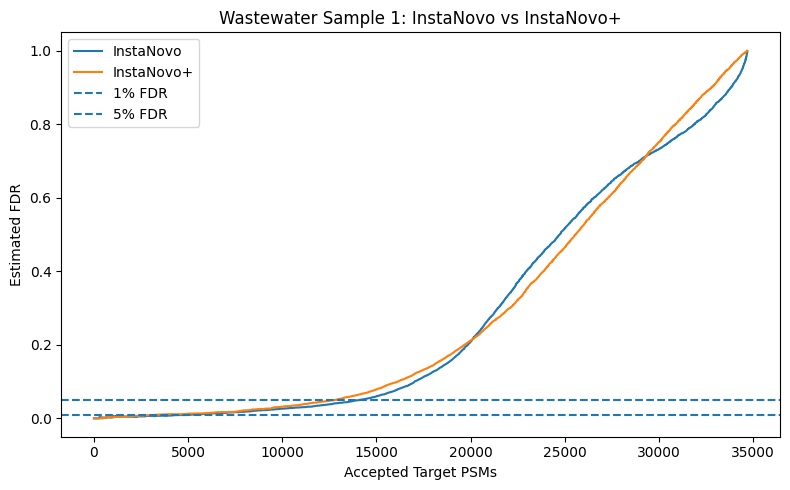

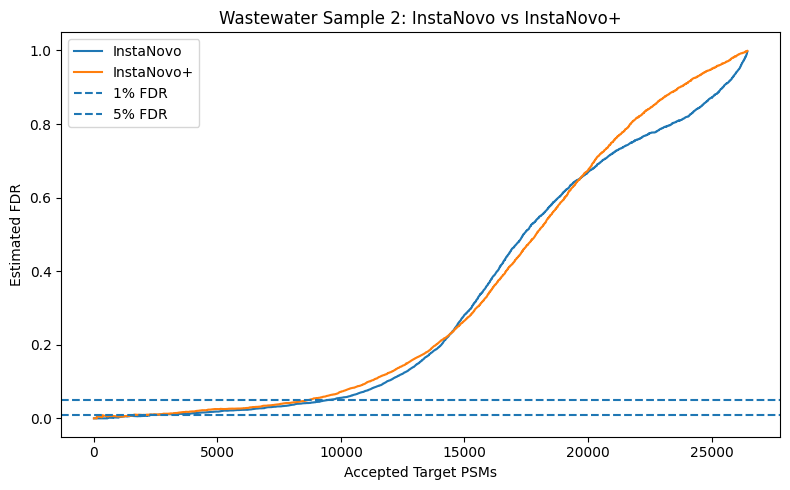

plots saved to: /content/drive/MyDrive/Wastewater/fdr_plots


In [ ]:
import os
import matplotlib.pyplot as plt

plot_dir = "/content/drive/MyDrive/Wastewater/fdr_plots"
os.makedirs(plot_dir, exist_ok=True)

# Sample 1
plt.figure(figsize=(8, 5))
plt.plot(w1_in["accepted_target_psms"], w1_in["estimated_fdr"], label="InstaNovo")
plt.plot(w1_plus["accepted_target_psms"], w1_plus["estimated_fdr"], label="InstaNovo+")
plt.axhline(0.01, linestyle="--", label="1% FDR")
plt.axhline(0.05, linestyle="--", label="5% FDR")
plt.xlabel("Accepted Target PSMs")
plt.ylabel("Estimated FDR")
plt.title("Wastewater Sample 1: InstaNovo vs InstaNovo+")
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/wastewater_sample1_instanovo_vs_instanovoplus_fdr.png", dpi=300)
plt.show()

# Sample 2
plt.figure(figsize=(8, 5))
plt.plot(w2_in["accepted_target_psms"], w2_in["estimated_fdr"], label="InstaNovo")
plt.plot(w2_plus["accepted_target_psms"], w2_plus["estimated_fdr"], label="InstaNovo+")
plt.axhline(0.01, linestyle="--", label="1% FDR")
plt.axhline(0.05, linestyle="--", label="5% FDR")
plt.xlabel("Accepted Target PSMs")
plt.ylabel("Estimated FDR")
plt.title("Wastewater Sample 2: InstaNovo vs InstaNovo+")
plt.legend()
plt.tight_layout()
plt.savefig(f"{plot_dir}/wastewater_sample2_instanovo_vs_instanovoplus_fdr.png", dpi=300)
plt.show()

print("plots saved to:", plot_dir)

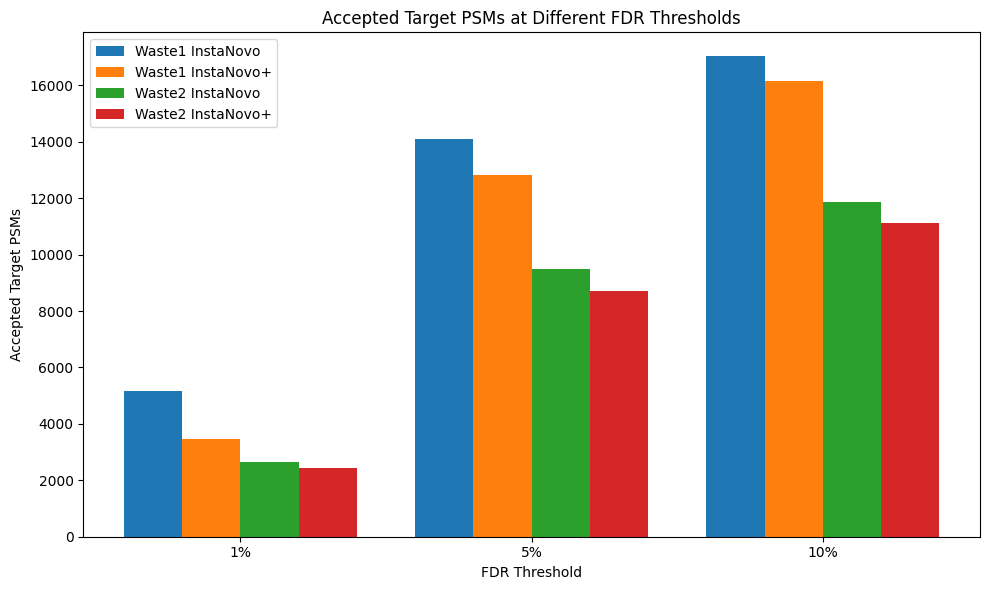

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

bar_df = pd.DataFrame({
    "FDR": ["1%", "5%", "10%"],
    "Waste1_InstaNovo": summary_w1["accepted_target_psms"],
    "Waste1_InstaNovoPlus": summary_plus_w1["accepted_target_psms"],
    "Waste2_InstaNovo": summary_w2["accepted_target_psms"],
    "Waste2_InstaNovoPlus": summary_plus_w2["accepted_target_psms"],
})

x = np.arange(len(bar_df["FDR"]))
width = 0.2

plt.figure(figsize=(10, 6))
plt.bar(x - 1.5*width, bar_df["Waste1_InstaNovo"], width, label="Waste1 InstaNovo")
plt.bar(x - 0.5*width, bar_df["Waste1_InstaNovoPlus"], width, label="Waste1 InstaNovo+")
plt.bar(x + 0.5*width, bar_df["Waste2_InstaNovo"], width, label="Waste2 InstaNovo")
plt.bar(x + 1.5*width, bar_df["Waste2_InstaNovoPlus"], width, label="Waste2 InstaNovo+")

plt.xticks(x, bar_df["FDR"])
plt.xlabel("FDR Threshold")
plt.ylabel("Accepted Target PSMs")
plt.title("Accepted Target PSMs at Different FDR Thresholds")
plt.legend()
plt.tight_layout()
plt.show()

E. coli UniPept input string

In [ ]:
import os
import re
import ast
import numpy as np
import pandas as pd

def clean_peptide_for_unipept(x):
    if pd.isna(x):
        return ""

    s = str(x).strip()

    # case 1: list-like peptide, e.g. "['V', 'C', 'P', 'A', 'G', 'Y', 'R']"
    if s.startswith("[") and s.endswith("]"):
        try:
            obj = ast.literal_eval(s)
            if isinstance(obj, list):
                s = "".join(str(t) for t in obj)
            else:
                s = str(obj)
        except Exception:
            pass

    # case 2: comma-separated tokens, e.g. "V, C, P, A, G, Y, R"
    if "," in s:
        parts = [p.strip().strip("'").strip('"') for p in s.split(",")]
        s = "".join(parts)

    # remove quotes / spaces
    s = s.replace("'", "").replace('"', "").replace(" ", "")

    # remove UNIMOD tags
    s = re.sub(r"\[UNIMOD:\d+\]", "", s)

    # remove numeric modifications like (+15.99), (+79.97), (-17.03)
    s = re.sub(r"\([+\-]?\d+(\.\d+)?\)", "", s)

    # remove named modifications like M(Oxidation), C(Carbamidomethylation)
    s = re.sub(r"\((Oxidation|Carbamidomethylation|Deamidation|Phosphorylation)\)", "", s)

    # keep only letters
    s = re.sub(r"[^A-Za-z]", "", s).upper()

    return s


def build_unipept_input(df, peptide_col, out_txt_path=None, deduplicate=True, min_len=1):
    peptides = df[peptide_col].dropna().map(clean_peptide_for_unipept)
    peptides = peptides[peptides.str.len() >= min_len]

    if deduplicate:
        peptides = pd.Series(peptides.unique())

    peptide_list = peptides.tolist()
    peptide_string = "\n".join(peptide_list)

    if out_txt_path is not None:
        with open(out_txt_path, "w") as f:
            f.write(peptide_string)

    return peptide_string, peptide_list

In [ ]:
print("eco_in_fdr columns:", eco_in_fdr.columns.tolist())
print("eco_ip_fdr columns:", eco_ip_fdr.columns.tolist())

print("InstaNovo min q_value:", eco_in_fdr["q_value"].min())
print("InstaNovo+ min q_value:", eco_ip_fdr["q_value"].min())

print("InstaNovo <=1%:", (eco_in_fdr["q_value"] <= 0.01).sum())
print("InstaNovo <=5%:", (eco_in_fdr["q_value"] <= 0.05).sum())
print("InstaNovo+ <=1%:", (eco_ip_fdr["q_value"] <= 0.01).sum())
print("InstaNovo+ <=5%:", (eco_ip_fdr["q_value"] <= 0.05).sum())

eco_in_fdr columns: ['fraction', 'scan_number', 'ground_truth_raw', 'ground_truth', 'pep', 'score', 'experiment_name', 'spectrum_id', 'precursor_mz', 'precursor_charge', 'prediction_id', 'predictions', 'log_probs', 'token_log_probs', 'group', 'instanovo_predictions', 'instanovo_prediction_log_probability', 'instanovo_prediction_token_log_probabilities', 'instanovo_predictions_beam_0', 'instanovo_predictions_log_probability_beam_0', 'instanovo_predictions_token_log_probabilities_beam_0', 'instanovo_predictions_beam_1', 'instanovo_predictions_log_probability_beam_1', 'instanovo_predictions_token_log_probabilities_beam_1', 'instanovo_predictions_beam_2', 'instanovo_predictions_log_probability_beam_2', 'instanovo_predictions_token_log_probabilities_beam_2', 'instanovo_predictions_beam_3', 'instanovo_predictions_log_probability_beam_3', 'instanovo_predictions_token_log_probabilities_beam_3', 'instanovo_predictions_beam_4', 'instanovo_predictions_log_probability_beam_4', 'instanovo_predictio

In [ ]:
ecoli_unipept_dir = "/content/drive/MyDrive/Ecoli_FDR_Results/unipept_inputs"
os.makedirs(ecoli_unipept_dir, exist_ok=True)

# choose threshold automatically
eco_in_use = eco_in_fdr[eco_in_fdr["q_value"] <= 0.01].copy()
if len(eco_in_use) == 0:
    eco_in_use = eco_in_fdr[eco_in_fdr["q_value"] <= 0.05].copy()
    print("E. coli InstaNovo: no peptides at 1% FDR, using 5% FDR")

eco_ip_use = eco_ip_fdr[eco_ip_fdr["q_value"] <= 0.01].copy()
if len(eco_ip_use) == 0:
    eco_ip_use = eco_ip_fdr[eco_ip_fdr["q_value"] <= 0.05].copy()
    print("E. coli InstaNovo+: no peptides at 1% FDR, using 5% FDR")

# pick peptide columns that actually exist
eco_in_peptide_col = "instanovo_predictions" if "instanovo_predictions" in eco_in_use.columns else "predictions"
eco_ip_peptide_col = "instanovoplus_predictions" if "instanovoplus_predictions" in eco_ip_use.columns else "predictions"

eco_in_string, eco_in_list = build_unipept_input(
    eco_in_use,
    peptide_col=eco_in_peptide_col,
    out_txt_path=f"{ecoli_unipept_dir}/ecoli_instanovo_unipept.txt"
)

eco_ip_string, eco_ip_list = build_unipept_input(
    eco_ip_use,
    peptide_col=eco_ip_peptide_col,
    out_txt_path=f"{ecoli_unipept_dir}/ecoli_instanovoplus_unipept.txt"
)

print("E. coli InstaNovo peptides:", len(eco_in_list))
print("E. coli InstaNovo+ peptides:", len(eco_ip_list))
print("\nFirst few InstaNovo peptides:")
print("\n".join(eco_in_list[:10]))
print("\nFirst few InstaNovo+ peptides:")
print("\n".join(eco_ip_list[:10]))

E. coli InstaNovo peptides: 22
E. coli InstaNovo+ peptides: 22

First few InstaNovo peptides:
YPNNPGAK
QMLMVLAPK
DQFVQPVVK
HAVTEASPMVK
YGYAYPR
VQFLDEPVK
SHALNATK
YDSSATLDEMK
NKPGVYTK
VWVVEGSK

First few InstaNovo+ peptides:
QDGSVDFGR
VATVSLPR
DVVTQPQA
YGYAYPR
FENMGAQMVK
VGAATEVEMK
AGQYAYR
YVDVGATYYFNK
MWEFFER
DDEVIVLTGK


In [ ]:
# Waste water instanovo

waste_unipept_dir = "/content/drive/MyDrive/Wastewater/unipept_inputs"
os.makedirs(waste_unipept_dir, exist_ok=True)

w1_string, w1_list = build_unipept_input(
    accepted_w1_1pct,
    peptide_col="Peptide",
    out_txt_path=f"{waste_unipept_dir}/waste1_instanovo_unipept_1pct.txt"
)

w2_string, w2_list = build_unipept_input(
    accepted_w2_1pct,
    peptide_col="Peptide",
    out_txt_path=f"{waste_unipept_dir}/waste2_instanovo_unipept_1pct.txt"
)

print("Waste 1 InstaNovo peptides:", len(w1_list))
print("Waste 2 InstaNovo peptides:", len(w2_list))
print("\nFirst few Waste 1 peptides:")
print("\n".join(w1_list[:10]))

Waste 1 InstaNovo peptides: 3616
Waste 2 InstaNovo peptides: 1672

First few Waste 1 peptides:
VVTTNTPVK
STFPSSGR
GSSIFGLAPSK
VYTTTPK
YVSATPSK
CVCPAGYR
QVQVQVNR
LPVVLANGQIR
AVFPSIVGR
SFGSNVYGR


In [ ]:
# waster water insta novo plus
w1_plus_string, w1_plus_list = build_unipept_input(
    accepted_plus_w1_1pct,
    peptide_col="Peptide",
    out_txt_path=f"{waste_unipept_dir}/waste1_instanovoplus_unipept_1pct.txt"
)

w2_plus_string, w2_plus_list = build_unipept_input(
    accepted_plus_w2_1pct,
    peptide_col="Peptide",
    out_txt_path=f"{waste_unipept_dir}/waste2_instanovoplus_unipept_1pct.txt"
)

print("Waste 1 InstaNovo+ peptides:", len(w1_plus_list))
print("Waste 2 InstaNovo+ peptides:", len(w2_plus_list))
print("\nFirst few Waste 1 InstaNovo+ peptides:")
print("\n".join(w1_plus_list[:10]))

Waste 1 InstaNovo+ peptides: 2536
Waste 2 InstaNovo+ peptides: 1595

First few Waste 1 InstaNovo+ peptides:
TFTAVPVGK
TATGAASHNAAR
GSHQTTAAAVSGSGK
GNYASTGVSR
STFPSSGR
GNPAVSYVR
GFSSGSAVVSGGSR
SVVYVTR
GSQAVSYTR
SASSLGGGFGGGSR
